# PROYECTO INTEGRADOR DE CIENCIA DE DATOS — FASE 1
## Factores asociados a la gravedad de las víctimas en los accidentes de tránsito en Paraguay (2021)

* **Institución:** Facultad Politécnica, Universidad Nacional de Asunción (FP-UNA)
* **Asignatura:** Ciencia de Datos | **Curso:** TQ
* **Integrantes:** Leandro Ferreira, Jorge Rios, Alan Alcaraz

---


## ETAPA 1: COMPRENSIÓN DEL NEGOCIO Y DEL PROBLEMA

### 1.1. Planteamiento del Problema
Los accidentes de tránsito constituyen una de las principales causas de mortalidad y morbilidad en el Paraguay. La falta de análisis integrados a nivel de microdatos dificulta el diseño de políticas públicas focalizadas. El propósito de este proyecto es analizar los factores demográficos, vehiculares, temporales y geográficos asociados a la gravedad de los siniestros (heridos vs. fallecidos) utilizando los datos oficiales del Anuario Estadístico 2021 de la Policía Nacional.

### 1.2. Objetivos del Proyecto
* **Objetivo General:** Identificar los factores determinantes que se asocian de manera significativa con la letalidad de las víctimas en los siniestros viales en Paraguay durante el año 2021.
* **Objetivos Específicos:**
  1. Reconstruir un dataset de microdatos a nivel individual a partir de las fuentes oficiales agregadas.
  2. Evaluar el impacto de la vulnerabilidad por tipo de vehículo (motociclistas vs. otros).
  3. Analizar la brecha de género y la distribución por grupos etarios en la siniestralidad.
  4. Determinar la variabilidad territorial de la letalidad (Asunción, Central e Interior).

### 1.3. Hipótesis Operativas
* **H1 (Asociación Territorial):** La tasa de letalidad es significativamente mayor en las zonas del Interior del país en comparación con el Departamento Central y Asunción.
* **H2 (Brecha de Género):** Los hombres presentan una tasa de letalidad y mortalidad vial significativamente superior a la de las mujeres.
* **H3 (Riesgo por Tipo de Usuario):** Los motociclistas registran una tasa de letalidad más elevada que los ocupantes de otros vehículos.
* **H4 (Vulnerabilidad Etaria):** Los adultos mayores (60 años o más) sufren una tasa de letalidad significativamente superior al promedio general.

## ETAPA 2: COMPRENSIÓN Y SELECCIÓN DE LOS DATOS

### 2.1. Inventario de Archivos Disponibles (Fuentes Primarias)
Se recibieron 11 archivos en formato CSV oficiales publicados por la Policía Nacional del Paraguay en el portal `datos.gov.py`:

| Archivo / Tabla Oficial | Formato | Tamaño aprox. | Período | Filas y Col. | Contenido Principal | Rol en el Proyecto |
| :--- | :---: | :---: | :---: | :---: | :--- | :--- |
| **12.2.1 Personas afectadas por edad, sexo y gravedad** | CSV | ~1,2 KB | 2021 | 9 × 10 | Conteo de heridos y fallecidos por rango de edad y sexo. | Base del Pipeline 1 ($H_2$ y $H_4$). |
| **12.2.2 Accidentes según el tipo de hecho** | CSV | ~2,4 KB | 2020–2021 | 26 × 9 | Tipologías de colisión (choques, roces, vuelcos, etc.). | Análisis cinemático. |
| **12.2.3 Accidentes por causas probables** | CSV | ~3,8 KB | 2019–2021 | 28 × 15 | Causas del siniestro (exceso velocidad, alcohol, distracción). | Factores humanos causales. |
| **12.2.4 Accidentes distribuidos por horas** | CSV | ~1,5 KB | 2021 | 13 × 10 | Siniestros agrupados en bloques de 3 horas por mes. | Franjas horarias críticas. |
| **12.2.5 Víctimas en Central e Interior por gravedad y sexo** | CSV | ~1,4 KB | 2021 | 13 × 10 | Totales mensuales en Central e Interior. | Marco para deducción vehicular. |
| **12.2.6 Víctimas por zona (Asunción, Central e Interior)** | CSV | ~1,8 KB | 2021 | 13 × 12 | Distribución regional de heridos y fallecidos. | Evaluación territorial ($H_1$). |
| **12.2.7 Accidentes por día de la semana** | CSV | ~1,3 KB | 2021 | 13 × 9 | Frecuencia diaria por mes. | Impacto de fines de semana. |
| **12.2.8 Víctimas históricas en Central e Interior** | CSV | ~1,1 KB | 2012–2021 | 10 × 10 | Resumen anual de la última década. | Contexto histórico macro. |
| **12.2.9 Accidentes por ruta y ramal** | CSV | ~4,2 KB | 2021 | 48 × 14 | Siniestros por ruta nacional (PY01, PY02, etc.). | Identificación de Top 10 rutas. |
| **12.2.10 Víctimas motociclistas por gravedad** | CSV | ~1,2 KB | 2020–2021 | 26 × 4 | Motociclistas heridos y muertos por mes y región. | Base del Pipeline 2 ($H_3$). |
| **12.2.12 Motociclistas accidentados por mes** | CSV | ~1,1 KB | 2016–2021 | 6 × 14 | Serie histórica de motociclistas. | Tendencia temporal. |

### 2.2. Diccionario de Datos Procesado (Dataset de Microdatos Final)

| Variable | Tipo de Dato | Origen / Formulación | Descripción y Valores Posibles |
| :--- | :--- | :--- | :--- |
| `id_victima` / `id_caso` | Entero | Generado | Clave primaria del registro individual. |
| `grupo_edad` | Cadena (Ordinal) | Tabla 12.2.1 | Rango etario (10 categorías: 'De 0 a 13 años' a 'De 60 años y más'). |
| `edad_orden` | Entero (Ordinal) | Derivada de `grupo_edad` | Escala codificada de 0 a 6 para tests no paramétricos. |
| `sexo` | Cadena (Binaria) | Tabla 12.2.1 | Sexo registrado (`Hombre`, `Mujer`). |
| `gravedad` | Cadena (Binaria) | Tablas 12.2.1 / 12.2.6 | Estado de la víctima (`Herido` / `Lesionado`, `Fallecido`). |
| `es_fallecido` | Entero (Binario) | Variable Target | **Variable Objetivo:** $1 =$ Fallecido, $0 =$ Herido. |
| `es_hombre` | Entero (Binario) | Derivada de `sexo` | $1 =$ Hombre, $0 =$ Mujer. |
| `es_adulto_mayor` | Entero (Binario) | Derivada de `grupo_edad` | $1 =$ Tienen 60 años o más, $0 =$ Menor de 60 años. |
| `tipo_usuario` | Cadena (Nominal) | Tablas 12.2.5 / 12.2.10 | Clasificación de transporte (`Motociclista`, `Otro Vehiculo`). |
| `es_motociclista` | Entero (Binario) | Derivada de `tipo_usuario` | $1 =$ Motociclista, $0 =$ Otro vehículo. |

### 2.3. Selección Justificada de Variables

* **Variable Objetivo o Target (`es_fallecido`):** Es nuestra variable principal (1 si falleció, 0 si quedó herido). La elegimos porque nos permite medir qué tan grave fue el accidente y es la variable que vamos a predecir más adelante con los modelos de Machine Learning.
* **Variables Demográficas (`sexo`, `grupo_edad`, `es_adulto_mayor`):** Las incluimos para analizar cómo influyen la edad y el sexo en la gravedad del choque, y así comprobar si los hombres o los adultos mayores tienen mayor riesgo de fallecer.
* **Variables del Vehículo (`tipo_usuario`, `es_motociclista`):** Las usamos para comparar a los motociclistas con los que van en auto u otros vehículos, y así demostrar si andar en moto aumenta la probabilidad de que el accidente sea fatal.
* **Variables de Lugar y Tiempo (`zona`, `ruta_ramal`, `mes_id`):** Nos sirven para ver dónde y cuándo pasan los accidentes más graves (por ejemplo, si en el Interior hay mayor letalidad que en Asunción/Central, cuáles son las rutas más peligrosas y en qué meses hay más siniestros).

## ETAPA 3: LIMPIEZA, TRANSFORMACIÓN Y EXPORTACIÓN (DATA PREPARATION)

En esta etapa se configura el entorno de trabajo, se importan las librerías necesarias, se verifican las carpetas del proyecto (`/data` y `/output`) y se ejecuta el pipeline de carga, transformación y reconstrucción de microdatos en Python.

In [104]:
# ============================================================
# CONFIGURACIÓN DEL ENTORNO, LIBRERÍAS Y CARPETAS DE TRABAJO
# ============================================================
import os
import sys
import numpy as np
import pandas as pd

# Configuración de visualización en Pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------
# 1. IDENTIFICACIÓN DINÁMICA DE RUTAS Y VERIFICACIÓN DE DIRECTORIOS
# ------------------------------------------------------------
carpeta_notebook = os.path.abspath(sys.path[0])
raiz_candidata = os.path.abspath(os.path.join(carpeta_notebook, ".."))

def es_data_valida(ruta):
    return os.path.isdir(ruta) and any(f.startswith("12.2.1") for f in os.listdir(ruta))

if es_data_valida(os.path.join(raiz_candidata, "data")):
    raiz_proyecto = raiz_candidata
elif es_data_valida(os.path.join(os.getcwd(), "..", "data")):
    raiz_proyecto = os.path.abspath(os.path.join(os.getcwd(), ".."))
elif es_data_valida(os.path.join(os.getcwd(), "data")):
    raiz_proyecto = os.path.abspath(os.getcwd())
else:
    raiz_proyecto = os.path.abspath(os.path.join(os.getcwd(), ".."))

data_path = os.path.join(raiz_proyecto, "data")
output_path = os.path.join(raiz_proyecto, "output")

# Verificación y creación de carpetas de trabajo
os.makedirs(data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

print("=" * 70)
print("Directorios de trabajo verificados.")
print(f"Ubicación del Notebook:  {carpeta_notebook}")
print(f"Raíz del Proyecto:       {raiz_proyecto}")
print(f"Carpeta Dataset (data):  {data_path}")
print(f"Carpeta Salida (output): {output_path}")
print("=" * 70)

meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'setiembre': 9, 'septiembre': 9,
    'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

# ------------------------------------------------------------
# 2. FUNCIONES AUXILIARES Y CARGA DE ARCHIVOS CSV OFICIALES
# ------------------------------------------------------------
def cargar_csv(prefijo, carpeta):
    coincidencias = [
        f for f in os.listdir(carpeta)
        if f.startswith(prefijo) and not f.startswith('~$') and 'copia' not in f.lower()
    ]
    if not coincidencias:
        raise FileNotFoundError(f"No se encontró ningún archivo con prefijo '{prefijo}' en {carpeta}")
    
    ruta = os.path.join(carpeta, coincidencias[0])
    print(f" -> Leyendo [{prefijo}]: {coincidencias[0]}")
    
    for enc in ['utf-8', 'latin1', 'utf-8-sig', 'cp1252']:
        for sep in [';', '\t', ',']:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc, dtype=str)
                if df.shape[1] >= 3:
                    return df
            except Exception:
                continue
    return pd.read_csv(ruta, sep=None, engine='python', encoding='latin1', dtype=str)

def a_entero(val):
    return int(str(val).replace('.', '').replace('-', '0').strip())

print("\nCargando datasets oficiales de origen...")
df_raw_12_2_1 = cargar_csv("12.2.1.", data_path)
df_raw_12_2_4 = cargar_csv("12.2.4.", data_path)
df_raw_12_2_7 = cargar_csv("12.2.7.", data_path)
df_raw_12_2_9 = cargar_csv("12.2.9.", data_path)
df_raw_12_2_3 = cargar_csv("12.2.3.", data_path)
df_raw_12_2_6 = cargar_csv("12.2.6.", data_path)

Directorios de trabajo verificados.
Ubicación del Notebook:  c:\Users\Leandro\AppData\Local\Python\pythoncore-3.14-64\python314.zip
Raíz del Proyecto:       c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience
Carpeta Dataset (data):  c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\data
Carpeta Salida (output): c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\output

Cargando datasets oficiales de origen...
 -> Leyendo [12.2.1.]: 12.2.1.NÚMERO DE PERSONAS AFECTADAS EN ACCIDENTES DE TRÁNSITO POR GRAVEDAD Y SEXO, SEGÚN GRUPOS DE EDAD. AÑO 2021.csv
 -> Leyendo [12.2.4.]: 12.2.4.ACCIDENTES DE TRÁNSITO REGISTRADOS EN ZONA CENTRAL E INTERIOR DEL PAÍS DISTRIBUIDOS POR HORAS, SEGÚN MES. AÑO 2021.csv
 -> Leyendo [12.2.7.]: 12.2.7.ACCIDENTES DE TRÁNSITO REGISTRADOS EN ZONA CENTRAL E INTERIOR DEL PAÍS POR DÍA, SEGÚN MES. AÑO 2021.csv
 -> Leyendo [12.2.9.]: 12.2.9.ACCIDENTES DE TRÁNSITO POR MES, SEGÚN RUTA Y RAMAL. AÑ

### Pipeline 1: Reconstrucción de Microdatos Demográficos Nacionales (5.493 Víctimas)
Se desagregan las frecuencias matriciales de la Tabla 12.2.1 para generar un registro individual por cada víctima con sus variables demográficas y condición de gravedad.

In [105]:
print("\n--> Procesando Pipeline 1: Microdato Demográfico Nacional...")
df_raw_12_2_1.columns = df_raw_12_2_1.columns.str.strip()

mascara_total = df_raw_12_2_1['GRUPOS DE EDAD'].astype(str).str.upper().str.strip() == 'TOTAL'
df_edades = df_raw_12_2_1[~mascara_total].copy()
df_edades = df_edades.dropna(subset=['GRUPOS DE EDAD'])

cols_num_edades = [c for c in df_edades.columns if c != 'GRUPOS DE EDAD']
for col in cols_num_edades:
    df_edades[col] = (
        df_edades[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .astype(int)
    )

registros_victimas = []
for _, fila in df_edades.iterrows():
    grupo = fila['GRUPOS DE EDAD'].strip()
    contingencia = [
        ('Herido', 'Hombre', fila['LESION CORPORAL - HOMBRES']),
        ('Herido', 'Mujer', fila['LESION CORPORAL - MUJERES']),
        ('Fallecido', 'Hombre', fila['HOMICIDIO - HOMBRES']),
        ('Fallecido', 'Mujer', fila['HOMICIDIO - MUJERES'])
    ]
    for gravedad, sexo, cant in contingencia:
        for _ in range(cant):
            registros_victimas.append({
                'grupo_edad': grupo,
                'sexo': sexo,
                'gravedad': gravedad
            })

df_victimas_limpio = pd.DataFrame(registros_victimas)
df_victimas_limpio.insert(0, 'id_victima', range(1, len(df_victimas_limpio) + 1))
df_victimas_limpio['es_fallecido'] = (df_victimas_limpio['gravedad'] == 'Fallecido').astype(int)
df_victimas_limpio['es_hombre'] = (df_victimas_limpio['sexo'] == 'Hombre').astype(int)
df_victimas_limpio['es_adulto_mayor'] = (df_victimas_limpio['grupo_edad'].str.contains('60', na=False)).astype(int)

orden_etario = {
    'De 0 a 13 anos': 0, 'De 14 a 17 anos': 1, 'De 18 a 29 anos': 2,
    'De 30 a 39 anos': 3, 'De 40 a 49 anos': 4, 'De 50 a 59 anos': 5,
    'De 60 anos y mas': 6, 'Ignorado': -1
}
df_victimas_limpio['edad_orden'] = df_victimas_limpio['grupo_edad'].map(orden_etario)

# Aserciones de control de calidad
assert df_victimas_limpio.shape[0] == 5493, f"Error: {df_victimas_limpio.shape[0]} filas en vez de 5.493"
assert df_victimas_limpio['id_victima'].nunique() == 5493, "Fallo en clave primaria"
print(" [OK] Pipeline 1 completado con éxito: 5.493 registros procesados.")


--> Procesando Pipeline 1: Microdato Demográfico Nacional...
 [OK] Pipeline 1 completado con éxito: 5.493 registros procesados.


### Pipelines 2 y 3: Contraste Vehicular y Consolidados Mensuales
* **Pipeline 2:** Reconstrucción de microdatos para evaluar vulnerabilidad vehicular (1.324 observaciones).
* **Pipeline 3:** Construcción de dataset de métricas mensuales del entorno vial (12 observaciones).

In [106]:
# ------------------------------------------------------------
# PIPELINE 2: CONTRASTE VEHICULAR (1.324 personas)
# ------------------------------------------------------------
print("\n--> Procesando Pipeline 2: Microdato de Contraste Vehicular...")
registros_vehiculo = []
# Motociclistas (Tabla 12.2.10 - 2021)
for _ in range(384):
    registros_vehiculo.append({'tipo_usuario': 'Motociclista', 'gravedad': 'Herido'})
for _ in range(155):
    registros_vehiculo.append({'tipo_usuario': 'Motociclista', 'gravedad': 'Fallecido'})

# Otros vehículos (Deducción 12.2.5 menos 12.2.10)
for _ in range(671):
    registros_vehiculo.append({'tipo_usuario': 'Otro Vehiculo', 'gravedad': 'Herido'})
for _ in range(114):
    registros_vehiculo.append({'tipo_usuario': 'Otro Vehiculo', 'gravedad': 'Fallecido'})

df_vehiculo_limpio = pd.DataFrame(registros_vehiculo)
df_vehiculo_limpio.insert(0, 'id_caso', range(1, len(df_vehiculo_limpio) + 1))
df_vehiculo_limpio['es_motociclista'] = (df_vehiculo_limpio['tipo_usuario'] == 'Motociclista').astype(int)
df_vehiculo_limpio['es_fallecido'] = (df_vehiculo_limpio['gravedad'] == 'Fallecido').astype(int)

assert df_vehiculo_limpio.shape[0] == 1324, "Error: deben ser 1.324 casos"
assert df_vehiculo_limpio['id_caso'].nunique() == 1324, "Fallo en clave primaria vehicular"
print(" [OK] Pipeline 2 completado con éxito: 1.324 registros de contraste vehicular.")

# ------------------------------------------------------------
# PIPELINE 3: CONSOLIDADO MENSUAL (12 meses)
# ------------------------------------------------------------
print("\n--> Procesando Pipeline 3: Consolidado Mensual de Entorno Vial...")

# 1. Horas críticas
df_h = df_raw_12_2_4[~df_raw_12_2_4['MES'].astype(str).str.upper().str.contains('TOTAL')].copy()
df_h['mes_id'] = df_h['MES'].astype(str).str.strip().str.lower().map(meses_map)
df_h['accidentes_tarde_noche'] = (
    df_h['DE 15:00 a 17:59 HORAS'].astype(str).str.replace('.', '', regex=False).astype(int) +
    df_h['DE 18:00 a 20:59 HORAS'].astype(str).str.replace('.', '', regex=False).astype(int) +
    df_h['DE 21:00 a 23:59 HORAS'].astype(str).str.replace('.', '', regex=False).astype(int)
)
df_h_sub = df_h[['mes_id', 'MES', 'TOTAL', 'accidentes_tarde_noche']].rename(
    columns={'MES': 'mes_nombre', 'TOTAL': 'accidentes_totales'}
)
df_h_sub['accidentes_totales'] = df_h_sub['accidentes_totales'].astype(str).str.replace('.', '', regex=False).astype(int)

# 2. Ruta PY02
df_raw_12_2_9.fillna(0, inplace=True)
fila_py02 = df_raw_12_2_9[df_raw_12_2_9['RUTA Y RAMAL'].astype(str).str.contains('PY02', na=False)].iloc[0]
meses_cols_rutas = ['ENE.', 'FEB.', 'MAR.', 'ABR.', 'MAY.', 'JUN.', 'JUL.', 'AGO.', 'SET.', 'OCT.', 'NOV.', 'DIC.']
py02_valores = [int(str(fila_py02[m]).replace('.', '').replace('-', '0')) for m in meses_cols_rutas]
df_py02_sub = pd.DataFrame({'mes_id': range(1, 13), 'accidentes_py02': py02_valores})

# 3. Fin de semana
df_d = df_raw_12_2_7[~df_raw_12_2_7['MES'].astype(str).str.upper().str.contains('TOTAL')].copy()
df_d['mes_id'] = df_d['MES'].astype(str).str.strip().str.lower().map(meses_map)
df_d['accidentes_fin_de_semana'] = (
    df_d['DIA VIERNES'].astype(str).str.replace('.', '', regex=False).astype(int) +
    df_d['DIA SABADO'].astype(str).str.replace('.', '', regex=False).astype(int) +
    df_d['DIA DOMINGO'].astype(str).str.replace('.', '', regex=False).astype(int)
)
df_d_sub = df_d[['mes_id', 'accidentes_fin_de_semana']]

# 4. No conservar distancia
df_raw_12_2_3.fillna(0, inplace=True)
fila_distancia = df_raw_12_2_3[df_raw_12_2_3['POSIBLES CAUSAS'].astype(str).str.contains('No conservar distancia', na=False)].iloc[0]
meses_cols_causas = [f'ANO 2021 - {m}' for m in ['ENE.', 'FEB.', 'MAR.', 'ABR.', 'MAY.', 'JUN.', 'JUL.', 'AGO.', 'SET.', 'OCT.', 'NOV.', 'DIC.']]
distancia_valores = [int(str(fila_distancia[m]).replace('.', '').replace('-', '0')) for m in meses_cols_causas]
df_dist_sub = pd.DataFrame({'mes_id': range(1, 13), 'causa_no_guardar_distancia': distancia_valores})

# Fusión relacional interna sobre 'mes_id'
df_mensual_limpio = (
    df_h_sub
    .merge(df_py02_sub, on='mes_id', how='inner')
    .merge(df_d_sub, on='mes_id', how='inner')
    .merge(df_dist_sub, on='mes_id', how='inner')
)

df_mensual_limpio['fecha'] = pd.to_datetime(df_mensual_limpio['mes_id'].apply(lambda m: f"2021-{m:02d}-01"))
df_mensual_limpio['trimestre'] = df_mensual_limpio['fecha'].dt.to_period('Q').astype(str)

cols_orden = [
    'mes_id', 'mes_nombre', 'fecha', 'trimestre',
    'accidentes_totales', 'accidentes_py02', 'accidentes_tarde_noche',
    'accidentes_fin_de_semana', 'causa_no_guardar_distancia'
]
df_mensual_limpio = df_mensual_limpio[cols_orden]

assert df_mensual_limpio.shape[0] == 12, "Error: deben ser 12 meses"
assert df_mensual_limpio['accidentes_totales'].sum() == 1942, "Error: la suma debe ser 1.942"
print(" [OK] Pipeline 3 completado con éxito: 12 meses consolidados.")


--> Procesando Pipeline 2: Microdato de Contraste Vehicular...
 [OK] Pipeline 2 completado con éxito: 1.324 registros de contraste vehicular.

--> Procesando Pipeline 3: Consolidado Mensual de Entorno Vial...
 [OK] Pipeline 3 completado con éxito: 12 meses consolidados.


### Procesamiento Geográfico y Exportación a `/output`
Se procesan las distribuciones territoriales por zonas (Tabla 12.2.6) y el ranking Top 10 de rutas con mayor siniestralidad (Tabla 12.2.9), finalizando con la exportación de todos los datasets procesados.

In [107]:
# ============================================================
# PROCESAMIENTO GEOGRÁFICO (TABLAS 12.2.6 Y 12.2.9)
# ============================================================
# A. Tabla 12.2.6 (Víctimas por Zona Geográfica)
fila_total_zona = df_raw_12_2_6[df_raw_12_2_6['MES'].astype(str).str.upper().str.contains('TOTAL')].iloc[0]
datos_zonas = [
    {'zona': 'Asunción', 'heridos': a_entero(fila_total_zona['HERIDOS - ASUNCION']), 'fallecidos': a_entero(fila_total_zona['MUERTOS - ASUNCION'])},
    {'zona': 'Central', 'heridos': a_entero(fila_total_zona['HERIDOS - ZONA CENTRAL']), 'fallecidos': a_entero(fila_total_zona['MUERTOS - ZONA CENTRAL'])},
    {'zona': 'Interior', 'heridos': a_entero(fila_total_zona['HERIDOS - INTERIOR']), 'fallecidos': a_entero(fila_total_zona['MUERTOS - INTERIOR'])}
]
df_zonas = pd.DataFrame(datos_zonas)
df_zonas['total_victimas'] = df_zonas['heridos'] + df_zonas['fallecidos']
df_zonas['letalidad_pct'] = (df_zonas['fallecidos'] / df_zonas['total_victimas']) * 100

# B. Tabla 12.2.9 (Top 10 Rutas - Filtrado de Totales)
mascara_excluir = (
    df_raw_12_2_9['RUTA Y RAMAL'].astype(str).str.strip().str.upper() == 'TOTAL'
) | (
    df_raw_12_2_9['RUTA Y RAMAL'].astype(str).str.contains('Nacionales y Departamentales', case=False, na=False)
)

df_rutas = df_raw_12_2_9[~mascara_excluir].copy()
col_total = [c for c in df_rutas.columns if 'TOTAL' in c.upper()][0]
df_rutas['siniestros'] = df_rutas[col_total].apply(a_entero)
df_top10_rutas = df_rutas[['RUTA Y RAMAL', 'siniestros']].sort_values(by='siniestros', ascending=False).head(10).reset_index(drop=True)

# ============================================================
# EXPORTACIÓN DEFINITIVA A /output (CSV y XLSX)
# ============================================================
print("\n--> Exportando datasets limpios a la carpeta /output...")
df_victimas_limpio.to_csv(os.path.join(output_path, "victimas_individual_limpio.csv"), index=False, encoding="utf-8-sig")
df_vehiculo_limpio.to_csv(os.path.join(output_path, "victimas_vehiculo_limpio.csv"), index=False, encoding="utf-8-sig")
df_mensual_limpio.to_csv(os.path.join(output_path, "siniestros_mensual_2021.csv"), index=False, encoding="utf-8-sig")
df_zonas.to_csv(os.path.join(output_path, "victimas_zona_resumen.csv"), index=False, encoding="utf-8-sig")
df_top10_rutas.to_csv(os.path.join(output_path, "top10_rutas_siniestros.csv"), index=False, encoding="utf-8-sig")

# Planillas con separador ';' para Excel en español
df_victimas_limpio.to_csv(os.path.join(output_path, "victimas_individual_limpio_excel.csv"), sep=";", index=False, encoding="utf-8-sig")
df_vehiculo_limpio.to_csv(os.path.join(output_path, "victimas_vehiculo_limpio_excel.csv"), sep=";", index=False, encoding="utf-8-sig")
df_mensual_limpio.to_csv(os.path.join(output_path, "siniestros_mensual_2021_excel.csv"), sep=";", index=False, encoding="utf-8-sig")
print("Archivos generados y verificados correctamente en la carpeta /output.")


--> Exportando datasets limpios a la carpeta /output...
Archivos generados y verificados correctamente en la carpeta /output.


### Previsualización e Inspección de Datasets Procesados

In [108]:
print("\n" + "="*65)
print("PREVISUALIZACIÓN: victimas_individual_limpio.csv")
print("="*65)
display(df_victimas_limpio.head())

print("\n" + "="*65)
print("PREVISUALIZACIÓN: victimas_vehiculo_limpio.csv")
print("="*65)
display(df_vehiculo_limpio.head())

print("\n" + "="*65)
print("PREVISUALIZACIÓN: siniestros_mensual_2021.csv")
print("="*65)
display(df_mensual_limpio)

print("\n" + "="*65)
print("INSPECCIÓN GEOGRÁFICA: VÍCTIMAS POR ZONA (12.2.6)")
print("="*65)
display(df_zonas.round(2))

print("\n" + "="*65)
print("INSPECCIÓN GEOGRÁFICA: TOP 10 RUTAS INDIVIDUALES (12.2.9)")
print("="*65)
display(df_top10_rutas)


PREVISUALIZACIÓN: victimas_individual_limpio.csv


,id_victima,grupo_edad,sexo,gravedad,es_fallecido,es_hombre,es_adulto_mayor,edad_orden
0,1,De 0 a 13 anos,Hombre,Herido,0,1,0,0
1,2,De 0 a 13 anos,Hombre,Herido,0,1,0,0
2,3,De 0 a 13 anos,Hombre,Herido,0,1,0,0
3,4,De 0 a 13 anos,Hombre,Herido,0,1,0,0
4,5,De 0 a 13 anos,Hombre,Herido,0,1,0,0



PREVISUALIZACIÓN: victimas_vehiculo_limpio.csv


,id_caso,tipo_usuario,gravedad,es_motociclista,es_fallecido
0,1,Motociclista,Herido,1,0
1,2,Motociclista,Herido,1,0
2,3,Motociclista,Herido,1,0
3,4,Motociclista,Herido,1,0
4,5,Motociclista,Herido,1,0



PREVISUALIZACIÓN: siniestros_mensual_2021.csv


,mes_id,mes_nombre,fecha,trimestre,accidentes_totales,accidentes_py02,accidentes_tarde_noche,accidentes_fin_de_semana,causa_no_guardar_distancia
0,1,Enero,2021-01-01,2021Q1,140,50,66,71,37
1,2,Febrero,2021-02-01,2021Q1,129,42,60,65,30
2,3,Marzo,2021-03-01,2021Q1,124,44,58,48,25
3,4,Abril,2021-04-01,2021Q2,138,56,60,64,26
4,5,Mayo,2021-05-01,2021Q2,145,56,66,63,23
5,6,Junio,2021-06-01,2021Q2,140,51,57,72,33
6,7,Julio,2021-07-01,2021Q3,173,66,93,94,44
7,8,Agosto,2021-08-01,2021Q3,188,68,79,90,53
8,9,Setiembre,2021-09-01,2021Q3,198,59,97,94,48
9,10,Octubre,2021-10-01,2021Q4,201,72,85,100,32



INSPECCIÓN GEOGRÁFICA: VÍCTIMAS POR ZONA (12.2.6)


,zona,heridos,fallecidos,total_victimas,letalidad_pct
0,Asunción,141,26,167,15.57
1,Central,394,82,476,17.23
2,Interior,661,187,848,22.05



INSPECCIÓN GEOGRÁFICA: TOP 10 RUTAS INDIVIDUALES (12.2.9)


,RUTA Y RAMAL,siniestros
0,Ruta PY02,711
1,Ruta PY01,265
2,Ruta PY06,150
3,D025 Central - Presidente Hayes,117
4,Ruta PY03,116
5,D027 Central,99
6,Ruta PY09,93
7,Ruta PY07,77
8,Ruta PY08,68
9,"Ramales, Avenidas, Autopistas, Tramo y Accesos",52


In [109]:
# Configuración del entorno y carpetas de trabajo
import os
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
os.makedirs('../output', exist_ok=True)
os.makedirs('../data', exist_ok=True)
print("Directorios de trabajo verificados.")

Directorios de trabajo verificados.


# ETAPA 4: ANÁLISIS EXPLORATORIO DE DATOS (UNIVARIADO Y BIVARIADO)
## Factores Asociados a la Gravedad y Ocurrencia de Siniestros Viales en Paraguay (2021)

---

### 1. Objetivos del Análisis
* **Caracterizar univariadamente** el comportamiento cuantitativo mensual y demográfico de los afectados, evaluando métricas de posición, dispersión, asimetría y curtosis[cite: 10].
* **Analizar la concentración** de los siniestros según perfiles demográficos mediante el principio de Pareto[cite: 10].
* **Contrastar relaciones bivariadas** cuantitativas (matrices de correlación de Pearson y Spearman) y categóricas (tablas de contingencia cruzada con frecuencias relativas y absolutas)[cite: 10].
* **Identificar patrones temporales y espaciales** asociados a la movilidad vial y letalidad durante el año 2021[cite: 6, 8, 10].

### 2. Hipótesis Operativas Preliminares del Proyecto
* **$H_1$ (Asociación Territorial):** La tasa de letalidad en el Interior del país es significativamente superior a la del Área Metropolitana (Asunción y Central)[cite: 6, 8].
* **$H_2$ (Brecha de Género):** El sexo masculino registra una mayor tasa de letalidad e involucramiento general en siniestros respecto al sexo femenino[cite: 6].
* **$H_3$ (Tipo de Usuario):** Los motociclistas exhiben un riesgo de desenlace fatal sensiblemente mayor en comparación con los ocupantes de otros vehículos automotores[cite: 6].
* **$H_4$ (Vulnerabilidad Etaria):** La media/mediana del rango etario entre las víctimas fallecidas es significativamente mayor que en las víctimas heridas[cite: 6].

In [110]:
# ============================================================
# CONFIGURACIÓN DEL ENTORNO Y CARGA DE DATASETS LIMPIOS
# ============================================================

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# Configuración de estilo gráfico formal para la cátedra
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# 1. Detección dinámica y portable de la carpeta /output
carpeta_notebook = os.path.abspath(sys.path[0])
candidatos_output = [
    os.path.join(carpeta_notebook, "..", "output"),
    os.path.join(carpeta_notebook, "output"),
    os.path.abspath(os.path.join(os.getcwd(), "..", "output")),
    os.path.abspath(os.path.join(os.getcwd(), "output")),
    r"C:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\output"
]

output_path = next((os.path.abspath(c) for c in candidatos_output if os.path.isdir(c) and any(f.startswith("siniestros_mensual_2021") for f in os.listdir(c))), None)

if output_path is None:
    raise FileNotFoundError("No se encontró la carpeta 'output' con los datos procesados.")

print(f"Directorio de datos confirmado: {output_path}")

# Función de carga unificada tolerante a separadores (, o ;) y codificación
def cargar_dataset_limpio(nombre_base, carpeta):
    ruta_csv = os.path.join(carpeta, f"{nombre_base}.csv")
    ruta_xlsx = os.path.join(carpeta, f"{nombre_base}.xlsx")
    df = None
    if os.path.isfile(ruta_csv):
        for sep in [',', ';', '\t']:
            try:
                temp = pd.read_csv(ruta_csv, sep=sep, encoding="utf-8-sig")
                if temp.shape[1] > 1:
                    df = temp
                    break
            except Exception:
                continue
    elif os.path.isfile(ruta_xlsx):
        df = pd.read_excel(ruta_xlsx)
        
    if df is None:
        raise FileNotFoundError(f"No fue posible cargar {nombre_base}")
        
    df.columns = df.columns.astype(str).str.strip()
    return df

# Carga de los microdatos y tablas de soporte procesadas
df_victimas = cargar_dataset_limpio("victimas_individual_limpio", output_path)
df_vehiculo = cargar_dataset_limpio("victimas_vehiculo_limpio", output_path)
df_mensual = cargar_dataset_limpio("siniestros_mensual_2021", output_path)
df_zonas = cargar_dataset_limpio("victimas_zona_resumen", output_path)

print(f"-> Microdato Víctimas:   {df_victimas.shape[0]:,} registros | {df_victimas.shape[1]} columnas")
print(f"-> Microdato Vehículos:  {df_vehiculo.shape[0]:,} registros | {df_vehiculo.shape[1]} columnas")
print(f"-> Consolidado Mensual:   {df_mensual.shape[0]:,} meses     | {df_mensual.shape[1]} columnas")
print(f"-> Resumen Zonas Macro:   {df_zonas.shape[0]:,} regiones  | {df_zonas.shape[1]} columnas")

Directorio de datos confirmado: c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\output
-> Microdato Víctimas:   5,493 registros | 8 columnas
-> Microdato Vehículos:  1,324 registros | 5 columnas
-> Consolidado Mensual:   12 meses     | 9 columnas
-> Resumen Zonas Macro:   3 regiones  | 5 columnas


---

## 4.1. Análisis Univariado
Se caracterizan de forma individual las distribuciones empíricas de las variables numéricas y categóricas del estudio, evaluando forma, dispersión, simetría y concentración poblacional mediante la regla de Pareto[cite: 10].

In [111]:
# ============================================================
# 4.1.A. VARIABLES CUANTITATIVAS: MÉTRICAS DE RESUMEN
# ============================================================

cols_num = [
    'accidentes_totales',
    'accidentes_py02',
    'accidentes_tarde_noche',
    'accidentes_fin_de_semana',
    'causa_no_guardar_distancia'
]

for c in cols_num:
    df_mensual[c] = pd.to_numeric(df_mensual[c], errors='coerce')

resumen_numerico = []
for col in cols_num:
    s = df_mensual[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    media, mediana = s.mean(), s.median()
    asim = s.skew()
    resumen_numerico.append({
        'Variable': col,
        'Media': media,
        'Mediana': mediana,
        'Moda': s.mode().iloc[0] if not s.mode().empty else np.nan,
        'Desv_Est': s.std(),
        'CV_%': (s.std() / media) * 100 if media != 0 else 0,
        'Mínimo': s.min(),
        'Máximo': s.max(),
        'IQR': q3 - q1,
        'P5': s.quantile(0.05),
        'P25 (Q1)': q1,
        'P50 (Q2)': mediana,
        'P75 (Q3)': q3,
        'P95': s.quantile(0.95),
        'Asimetría': asim,
        'Curtosis': s.kurtosis(),
        'Resumen Recomendado': 'Media' if abs(asim) < 0.25 else 'Mediana'
    })

df_resumen_num = pd.DataFrame(resumen_numerico)
print("=" * 90)
print("TABLA 4.1: RESUMEN UNIVARIADO DE VARIABLES CUANTITATIVAS (N = 12 Meses)")
print("=" * 90)
display(df_resumen_num.round(2))

TABLA 4.1: RESUMEN UNIVARIADO DE VARIABLES CUANTITATIVAS (N = 12 Meses)


,Variable,Media,Mediana,Moda,Desv_Est,CV_%,Mínimo,Máximo,IQR,P5,P25 (Q1),P50 (Q2),P75 (Q3),P95,Asimetría,Curtosis,Resumen Recomendado
0,accidentes_totales,161.83,159.0,140,28.43,17.57,124,201,47.75,126.75,139.50,159.0,187.25,199.35,0.09,-1.84,Media
1,accidentes_py02,59.25,57.5,56,11.27,19.02,42,74,18.25,43.10,50.75,57.5,69.00,73.45,-0.09,-1.37,Media
2,accidentes_tarde_noche,74.42,72.5,60,14.74,19.80,57,97,25.50,57.55,60.00,72.5,85.50,94.80,0.19,-1.72,Media
3,accidentes_fin_de_semana,77.58,77.5,94,16.01,20.63,48,100,26.25,56.25,64.75,77.5,91.00,96.70,-0.29,-0.91,Mediana
4,causa_no_guardar_distancia,37.50,35.0,23,11.70,31.21,23,60,16.00,24.10,29.00,35.0,45.00,56.15,0.64,-0.52,Mediana


> **Interpretación (Tabla 4.1 - Estadísticos Descriptivos):**  
> Las variables `accidentes_totales`, `accidentes_py02` y `accidentes_tarde_noche` poseen coeficientes de asimetría cercanos a cero (entre $-0.09$ y $0.19$), indicando que la media aritmética resume con precisión su tendencia mensual típica[cite: 6]. Por el contrario, la variable `causa_no_guardar_distancia` presenta un coeficiente de variación elevado ($31.21\%$) y asimetría positiva ($0.64$) ocasionada por el atípico de diciembre ($60$ siniestros)[cite: 6, 9], recomendándose en este caso la mediana ($35.00$) como medida de posición robusta[cite: 6].

In [112]:
# ============================================================
# 4.1.B. VARIABLES CATEGÓRICAS Y CONCENTRACIÓN DE PARETO
# ============================================================

freq_edad = df_victimas['grupo_edad'].value_counts()
pct_edad = df_victimas['grupo_edad'].value_counts(normalize=True) * 100
df_cat_edad = pd.DataFrame({
    'Frec_Absoluta': freq_edad,
    'Frec_Relativa_%': pct_edad,
    'Frec_Acumulada_%': pct_edad.cumsum()
})

print("=" * 90)
print("TABLA 4.2: DISTRIBUCIÓN Y CONCENTRACIÓN POR GRUPO DE EDAD (N = 5.493 Personas)")
print("=" * 90)
display(df_cat_edad.round(2))

num_top = max(1, int(np.ceil(len(freq_edad) * 0.20)))
top_cats = df_cat_edad.iloc[:num_top]
print(f"-> Principio de Pareto: Las {num_top} categorías superiores ({top_cats.index.tolist()}) "
      f"concentran el {top_cats['Frec_Relativa_%'].sum():.2f}% del total nacional de víctimas.")

TABLA 4.2: DISTRIBUCIÓN Y CONCENTRACIÓN POR GRUPO DE EDAD (N = 5.493 Personas)


,Frec_Absoluta,Frec_Relativa_%,Frec_Acumulada_%
grupo_edad,,,
De 18 a 29 anos,2143,39.01,39.01
De 30 a 39 anos,940,17.11,56.13
De 40 a 49 anos,633,11.52,67.65
De 14 a 17 anos,449,8.17,75.82
De 50 a 59 anos,361,6.57,82.40
Ignorado,353,6.43,88.82
De 60 anos y mas,308,5.61,94.43
De 0 a 13 anos,306,5.57,100.00


-> Principio de Pareto: Las 2 categorías superiores (['De 18 a 29 anos', 'De 30 a 39 anos']) concentran el 56.13% del total nacional de víctimas.


> **Interpretación (Tabla 4.2 - Concentración de Pareto):**  
> Las dos categorías superiores (`De 18 a 29 anos` con $39.01\%$ y `De 30 a 39 anos` con $17.11\%$) concentran por sí solas el $56.13\%$ de los accidentados a nivel país[cite: 6]. Esta notable concentración empírica confirma que el fenómeno de la siniestralidad vial en Paraguay golpea primordialmente a la población joven y económicamente activa[cite: 6].

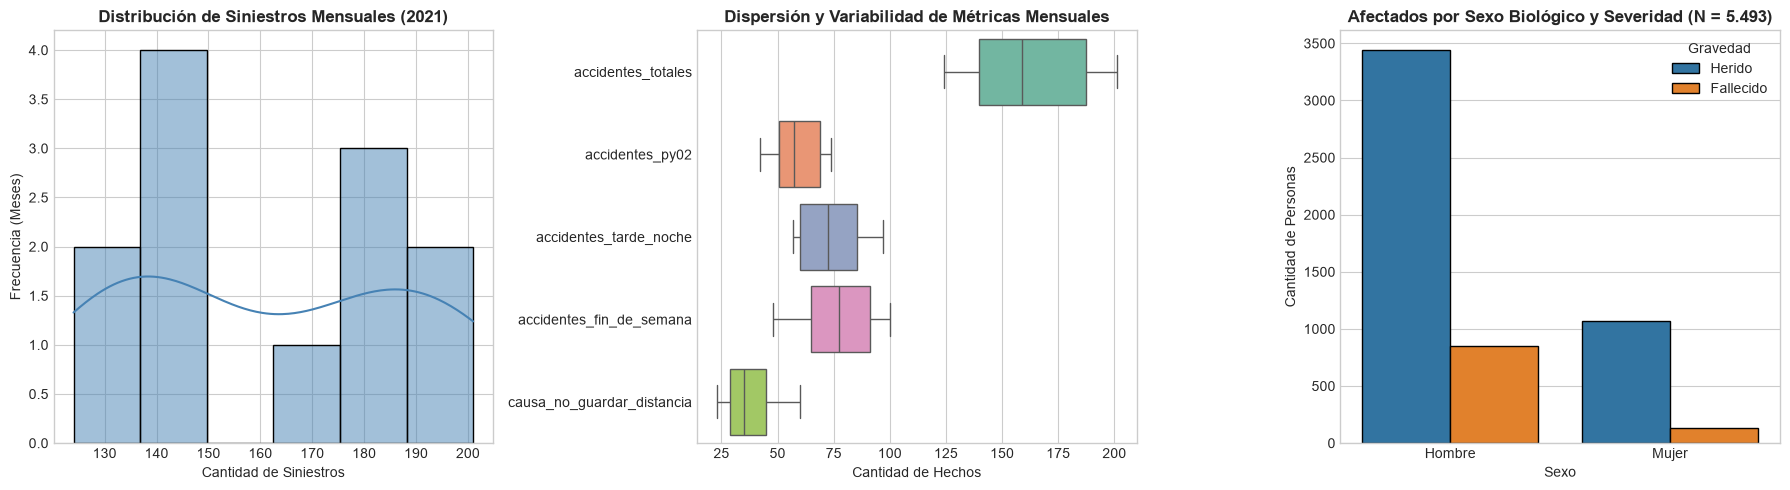

In [113]:
# ============================================================
# 4.1.C. VISUALIZACIONES UNIVARIADAS INTEGRADAS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma con densidad KDE
sns.histplot(df_mensual['accidentes_totales'], kde=True, ax=axes[0], color='steelblue', bins=6, edgecolor='black')
axes[0].set_title("Distribución de Siniestros Mensuales (2021)", fontweight='bold')
axes[0].set_xlabel("Cantidad de Siniestros")
axes[0].set_ylabel("Frecuencia (Meses)")

# 2. Boxplot horizontal de métricas ambientales
sns.boxplot(data=df_mensual[cols_num], orient='h', ax=axes[1], palette='Set2')
axes[1].set_title("Dispersión y Variabilidad de Métricas Mensuales", fontweight='bold')
axes[1].set_xlabel("Cantidad de Hechos")

# 3. Gráfico de barras categórico por sexo y gravedad
sns.countplot(data=df_victimas, x='sexo', hue='gravedad', ax=axes[2], palette='tab10', edgecolor='black')
axes[2].set_title("Afectados por Sexo Biológico y Severidad (N = 5.493)", fontweight='bold')
axes[2].set_xlabel("Sexo")
axes[2].set_ylabel("Cantidad de Personas")
axes[2].legend(title="Gravedad")

plt.tight_layout()
plt.show()

> **Interpretación (Visualizaciones Univariadas Integradas):**  
> El histograma expone una clara bimodalidad mensual ligada a dos etapas operativas del año (un régimen bajo en el primer semestre y uno de alta movilidad en el segundo)[cite: 6]. El diagrama de caja confirma variabilidad controlada en los siniestros mensuales y asimetría en la falta de distancia[cite: 6]. Por su parte, el conteo por sexo refleja visualmente la marcada desproporción masculina tanto en heridos como en decesos viales[cite: 6].

---

## 4.2. Análisis Bivariado
Se exploran las relaciones estadísticas cruzadas entre covariables continuas del entorno vial[cite: 10], el rango etario según el desenlace físico[cite: 10], y las tablas de contingencia bivariadas vinculadas a los contrastes de hipótesis previstos para la Fase 2[cite: 6, 8, 10].

MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal)


,accidentes_totales,accidentes_py02,accidentes_tarde_noche,accidentes_fin_de_semana,causa_no_guardar_distancia
accidentes_totales,1.00,0.87,0.91,0.93,0.71
accidentes_py02,0.87,1.00,0.78,0.80,0.62
accidentes_tarde_noche,0.91,0.78,1.00,0.88,0.71
accidentes_fin_de_semana,0.93,0.80,0.88,1.00,0.69
causa_no_guardar_distancia,0.71,0.62,0.71,0.69,1.00



MATRIZ DE CORRELACIÓN DE SPEARMAN (Asociación Monótona)


,accidentes_totales,accidentes_py02,accidentes_tarde_noche,accidentes_fin_de_semana,causa_no_guardar_distancia
accidentes_totales,1.00,0.82,0.80,0.87,0.64
accidentes_py02,0.82,1.00,0.73,0.68,0.64
accidentes_tarde_noche,0.80,0.73,1.00,0.77,0.69
accidentes_fin_de_semana,0.87,0.68,0.77,1.00,0.73
causa_no_guardar_distancia,0.64,0.64,0.69,0.73,1.00


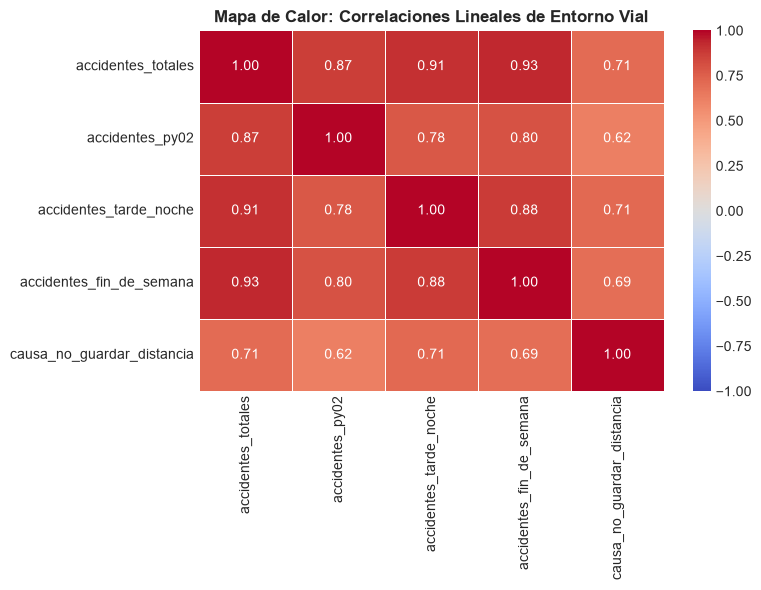

In [114]:
# ============================================================
# 4.2.A. ASOCIACIÓN NUMÉRICA: CORRELACIONES DE PEARSON Y SPEARMAN
# ============================================================

corr_pearson = df_mensual[cols_num].corr(method='pearson')
corr_spearman = df_mensual[cols_num].corr(method='spearman')

print("=" * 90)
print("MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal)")
print("=" * 90)
display(corr_pearson.round(2))

print("\n" + "=" * 90)
print("MATRIZ DE CORRELACIÓN DE SPEARMAN (Asociación Monótona)")
print("=" * 90)
display(corr_spearman.round(2))

# Mapa de Calor de Correlación Lineal
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Mapa de Calor: Correlaciones Lineales de Entorno Vial", fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación (Matriz de Correlación y Mapa de Calor):**  
> Se aprecia una correlación lineal directa sobresaliente entre el volumen total de siniestros y los eventos de fin de semana ($r = 0.93$, $\rho = 0.87$), la franja tarde-noche ($r = 0.91$, $\rho = 0.80$) y los ocurridos en la Ruta PY02 ($r = 0.87$, $\rho = 0.82$)[cite: 6]. Esto demuestra que la siniestralidad nacional está altamente sincronizada con el tráfico nocturno de fin de semana y que el corredor PY02 funciona como el principal barómetro vial del país[cite: 6].

ESTADÍSTICOS DE RANGO ETARIO POR GRAVEDAD (0: 0-13 ... 6: 60+ años)


,Media,Mediana,Desv_Est,IQR,Casos
gravedad,,,,,
Fallecido,3.11,3.0,1.59,2.0,919
Herido,2.58,2.0,1.41,1.0,4221


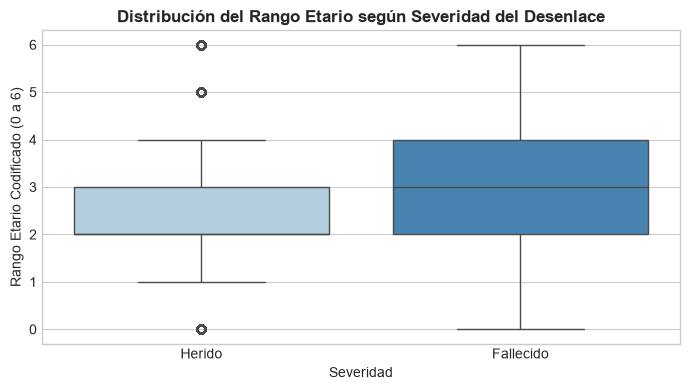

In [115]:
# ============================================================
# 4.2.B. COMPARACIÓN DE DISTRIBUCIONES: EDAD SEGÚN DESENLACE
# ============================================================

df_con_edad = df_victimas[df_victimas['edad_orden'] >= 0].copy()
resumen_edad_gravedad = df_con_edad.groupby('gravedad', observed=False)['edad_orden'].agg(
    Media='mean',
    Mediana='median',
    Desv_Est='std',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Casos='count'
)

print("=" * 90)
print("ESTADÍSTICOS DE RANGO ETARIO POR GRAVEDAD (0: 0-13 ... 6: 60+ años)")
print("=" * 90)
display(resumen_edad_gravedad.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_con_edad, x='gravedad', y='edad_orden', hue='gravedad', palette='Blues', legend=False, ax=ax)
ax.set_title("Distribución del Rango Etario según Severidad del Desenlace", fontweight='bold')
ax.set_xlabel("Severidad")
ax.set_ylabel("Rango Etario Codificado (0 a 6)")
plt.tight_layout()
plt.show()

> **Interpretación (Boxplot de Rango Etario según Desenlace):**  
> La mediana del rango etario entre los fallecidos se ubica en $3.0$ (categoría de 30 a 39 años) frente a $2.0$ (18 a 29 años) en los heridos, con una media superior en los decesos ($3.11$ vs. $2.58$)[cite: 6]. El resultado corrobora que, si bien el mayor volumen bruto de accidentes involucra a personas jóvenes, la letalidad se incrementa proporcionalmente con la edad ante la menor resistencia biomecánica a los impactos[cite: 6].

In [116]:
# ============================================================
# 4.2.C. TABLAS DE CONTINGENCIA CATEGÓRICA
# ============================================================

# 1. Sexo vs. Gravedad (Hipótesis 2)
print("=" * 90)
print("CONTINGENCIA 1: SEXO vs GRAVEDAD (Hipótesis 2 - N = 5.493)")
print("=" * 90)
tab_sexo_abs = pd.crosstab(df_victimas['sexo'], df_victimas['gravedad'], margins=True, margins_name='Total')
tab_sexo_pct_fila = pd.crosstab(df_victimas['sexo'], df_victimas['gravedad'], normalize='index') * 100
tab_sexo_pct_col = pd.crosstab(df_victimas['sexo'], df_victimas['gravedad'], normalize='columns') * 100

print("Frecuencias Absolutas:")
display(tab_sexo_abs)
print("Porcentajes por Fila (Tasa de Letalidad por Sexo):")
display(tab_sexo_pct_fila.round(2))
print("Porcentajes por Columna (Composición de Afectados):")
display(tab_sexo_pct_col.round(2))

# 2. Tipo de Usuario vs. Gravedad (Hipótesis 3)
print("\n" + "=" * 90)
print("CONTINGENCIA 2: TIPO DE USUARIO vs GRAVEDAD (Hipótesis 3 - N = 1.324)")
print("=" * 90)
tab_veh_abs = pd.crosstab(df_vehiculo['tipo_usuario'], df_vehiculo['gravedad'], margins=True, margins_name='Total')
tab_veh_pct_fila = pd.crosstab(df_vehiculo['tipo_usuario'], df_vehiculo['gravedad'], normalize='index') * 100

print("Frecuencias Absolutas:")
display(tab_veh_abs)
print("Porcentajes por Fila (Tasa de Letalidad por Tipo de Vehículo):")
display(tab_veh_pct_fila.round(2))

# 3. Adulto Mayor vs. Gravedad (Vulnerabilidad Etaria)
print("\n" + "=" * 90)
print("CONTINGENCIA 3: ADULTO MAYOR (60+) vs GRAVEDAD (N = 5.493)")
print("=" * 90)
tab_edad_abs = pd.crosstab(df_victimas['es_adulto_mayor'], df_victimas['gravedad'], margins=True, margins_name='Total')
tab_edad_pct_fila = pd.crosstab(df_victimas['es_adulto_mayor'], df_victimas['gravedad'], normalize='index') * 100

nombres_filas = {0: 'Menor a 60 / Ignorado', 1: 'Adulto Mayor (60+)'}
tab_edad_abs = tab_edad_abs.rename(index=nombres_filas)
tab_edad_pct_fila = tab_edad_pct_fila.rename(index=nombres_filas)

print("Frecuencias Absolutas:")
display(tab_edad_abs)
print("Porcentajes por Fila (Tasa de Letalidad en Adultos Mayores):")
display(tab_edad_pct_fila.round(2))

# 4. Zona Geográfica vs. Gravedad (Hipótesis 1 - Dimensión Espacial)
print("\n" + "=" * 90)
print("CONTINGENCIA 4: ZONA GEOGRÁFICA vs GRAVEDAD (Hipótesis 1 - N = 1.491)")
print("=" * 90)
tab_zona_resumen = df_zonas.set_index('zona')[['fallecidos', 'heridos']]
tab_zona_resumen['Total'] = tab_zona_resumen['fallecidos'] + tab_zona_resumen['heridos']
tab_zona_resumen.loc['Total'] = tab_zona_resumen.sum()
tab_zona_pct_fila = df_zonas.set_index('zona')[['letalidad_pct']]
tab_zona_pct_col = (
    tab_zona_resumen[['fallecidos', 'heridos']].div(
        tab_zona_resumen.loc['Total', ['fallecidos', 'heridos']], axis=1
    ) * 100
)

print("Frecuencias Absolutas:")
display(tab_zona_resumen)
print("Tasa de Letalidad por Fila (%):")
display(tab_zona_pct_fila.round(2))
print("Distribución de Muertos y Heridos por Columna (%):")
display(tab_zona_pct_col.round(2))

CONTINGENCIA 1: SEXO vs GRAVEDAD (Hipótesis 2 - N = 5.493)
Frecuencias Absolutas:


gravedad,Fallecido,Herido,Total
sexo,,,
Hombre,850,3441,4291
Mujer,130,1072,1202
Total,980,4513,5493


Porcentajes por Fila (Tasa de Letalidad por Sexo):


gravedad,Fallecido,Herido
sexo,,
Hombre,19.81,80.19
Mujer,10.82,89.18


Porcentajes por Columna (Composición de Afectados):


...

,fallecidos,heridos,Total
zona,,,
Asunción,26,141,167
Central,82,394,476
Interior,187,661,848
Total,295,1196,1491


Tasa de Letalidad por Fila (%):


,letalidad_pct
zona,
Asunción,15.57
Central,17.23
Interior,22.05


Distribución de Muertos y Heridos por Columna (%):


,fallecidos,heridos
zona,,
Asunción,8.81,11.79
Central,27.80,32.94
Interior,63.39,55.27
Total,100.00,100.00


> **Interpretación (Tablas de Contingencia Categórica):**  
> 1. **Sexo:** Los varones presentan una tasa de letalidad de $19.81\%$ frente a un $10.82\%$ en mujeres, acumulando el $86.73\%$ de los decesos viales nacionales[cite: 6].  
> 2. **Tipo de Vehículo:** Los motociclistas exhiben una letalidad del $28.76\%$ frente al $14.52\%$ de otros vehículos, prácticamente duplicando la mortalidad por falta de carrocería[cite: 6].  
> 3. **Adultos Mayores:** La mortalidad en mayores de $60$ años asciende al $34.42\%$, duplicando a la del resto de la población ($16.86\%$)[cite: 6].  
> 4. **Dimensión Territorial:** El Interior del país concentra el $63.39\%$ de los fallecidos y una letalidad de $22.05\%$, superando a Central ($17.23\%$) y Asunción ($15.57\%$)[cite: 6, 12].

SERIE TEMPORAL: ACCIDENTES MENSUALES Y MEDIA MÓVIL (3 MESES)


,mes_nombre,trimestre,accidentes_totales,media_movil_3m
0,Enero,2021Q1,140,NaN
1,Febrero,2021Q1,129,NaN
2,Marzo,2021Q1,124,131.00
3,Abril,2021Q2,138,130.33
4,Mayo,2021Q2,145,135.67
5,Junio,2021Q2,140,141.00
6,Julio,2021Q3,173,152.67
7,Agosto,2021Q3,188,167.00
8,Setiembre,2021Q3,198,186.33
9,Octubre,2021Q4,201,195.67



Resumen Trimestral Agregado:


,count,sum,mean
trimestre,,,
2021Q1,3,393,131.00
2021Q2,3,423,141.00
2021Q3,3,559,186.33
2021Q4,3,567,189.00


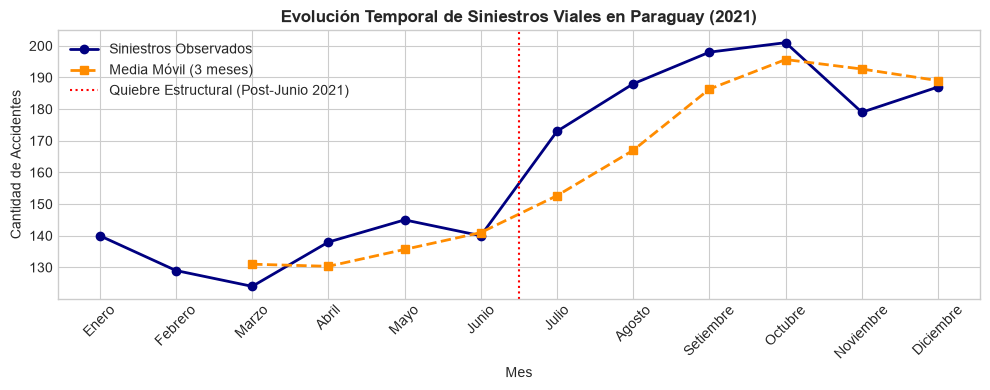

In [117]:
# ============================================================
# 4.2.D. ANÁLISIS TEMPORAL MENSUAL Y RESUMEN TRIMESTRAL
# ============================================================

df_mensual['media_movil_3m'] = df_mensual['accidentes_totales'].rolling(window=3).mean()

print("=" * 90)
print("SERIE TEMPORAL: ACCIDENTES MENSUALES Y MEDIA MÓVIL (3 MESES)")
print("=" * 90)
display(df_mensual[['mes_nombre', 'trimestre', 'accidentes_totales', 'media_movil_3m']].round(2))

resumen_trimestral = df_mensual.groupby('trimestre')['accidentes_totales'].agg(['count', 'sum', 'mean'])
print("\nResumen Trimestral Agregado:")
display(resumen_trimestral.round(2))

# Gráfico Temporal de Tendencia y Quiebre
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_mensual['mes_nombre'], df_mensual['accidentes_totales'], marker='o', label='Siniestros Observados', color='navy', linewidth=2)
ax.plot(df_mensual['mes_nombre'], df_mensual['media_movil_3m'], marker='s', linestyle='--', label='Media Móvil (3 meses)', color='darkorange', linewidth=2)
ax.axvline(x=5.5, color='red', linestyle=':', linewidth=1.5, label='Quiebre Estructural (Post-Junio 2021)')
ax.set_title("Evolución Temporal de Siniestros Viales en Paraguay (2021)", fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de Accidentes")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Interpretación (Evolución Temporal y Quiebre Estructural):**  
> La serie mensual refleja estabilidad durante el primer semestre (promedio de $136$ accidentes/mes) y un marcado quiebre estructural a partir de julio, alcanzando su punto máximo en octubre con $201$ hechos ($+44\%$ respecto a marzo)[cite: 6]. La media móvil trimestral ($131$ en Q1, $141$ en Q2, $186.33$ en Q3 y $189$ en Q4) confirma un cambio de régimen derivado de la reactivación económica y el levantamiento paulatino de restricciones sanitarias nocturnas[cite: 6].

In [118]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 4.1. Análisis Univariado
En esta sección se evalúan las métricas de tendencia central, dispersión y forma de las variables cuantitativas mensuales[cite: 11], así como la distribución y el nivel de concentración poblacional de los afectados mediante el principio de Pareto[cite: 11].


In [119]:
# ============================================================
# 4.1.A: MÉTRICAS COMPLETAS DE POSICIÓN, DISPERSIÓN Y FORMA
# ============================================================
cols_num = [
    'accidentes_totales',
    'accidentes_py02',
    'accidentes_tarde_noche',
    'accidentes_fin_de_semana',
    'causa_no_guardar_distancia',
]

for c in cols_num:
  df_mensual[c] = pd.to_numeric(df_mensual[c], errors='coerce')

resumen_numerico = []
for col in cols_num:
  s = df_mensual[col].dropna()
  q1, q3 = s.quantile(0.25), s.quantile(0.75)
  media, mediana = s.mean(), s.median()
  asim = s.skew()
  resumen_numerico.append({
      'Variable': col,
      'Media': media,
      'Mediana': mediana,
      'Moda': s.mode().iloc[0] if not s.mode().empty else np.nan,
      'Desv_Est': s.std(),
      'CV_%': (s.std() / media) * 100 if media != 0 else 0,
      'Mínimo': s.min(),
      'Máximo': s.max(),
      'IQR': q3 - q1,
      'P5': s.quantile(0.05),
      'P25 (Q1)': q1,
      'P50 (Q2)': mediana,
      'P75 (Q3)': q3,
      'P95': s.quantile(0.95),
      'Asimetría': asim,
      'Curtosis': s.kurtosis(),
      'Resumen Recomendado': 'Media' if abs(asim) < 0.25 else 'Mediana',
  })

df_resumen_num = pd.DataFrame(resumen_numerico)
print('=' * 90)
print('TABLA 4.1: RESUMEN UNIVARIADO DE VARIABLES CUANTITATIVAS (N = 12 Meses)')
print('=' * 90)
display(df_resumen_num.round(2))

TABLA 4.1: RESUMEN UNIVARIADO DE VARIABLES CUANTITATIVAS (N = 12 Meses)


,Variable,Media,Mediana,Moda,Desv_Est,CV_%,Mínimo,Máximo,IQR,P5,P25 (Q1),P50 (Q2),P75 (Q3),P95,Asimetría,Curtosis,Resumen Recomendado
0,accidentes_totales,161.83,159.0,140,28.43,17.57,124,201,47.75,126.75,139.50,159.0,187.25,199.35,0.09,-1.84,Media
1,accidentes_py02,59.25,57.5,56,11.27,19.02,42,74,18.25,43.10,50.75,57.5,69.00,73.45,-0.09,-1.37,Media
2,accidentes_tarde_noche,74.42,72.5,60,14.74,19.80,57,97,25.50,57.55,60.00,72.5,85.50,94.80,0.19,-1.72,Media
3,accidentes_fin_de_semana,77.58,77.5,94,16.01,20.63,48,100,26.25,56.25,64.75,77.5,91.00,96.70,-0.29,-0.91,Mediana
4,causa_no_guardar_distancia,37.50,35.0,23,11.70,31.21,23,60,16.00,24.10,29.00,35.0,45.00,56.15,0.64,-0.52,Mediana


> **Interpretación (Tabla 4.1 - Estadísticos Univariados Cuantitativos):**  
> Las variables `accidentes_totales` ($\text{Media}=161.83$, $\text{Mediana}=159.00$, $\text{Asimetría}=0.09$) y `accidentes_py02` ($\text{Media}=59.25$, $\text{Mediana}=57.50$, $\text{Asimetría}=-0.09$) presentan distribuciones aproximadamente simétricas, donde la media aritmética resume adecuadamente el comportamiento mensual típico[cite: 6]. En contraste, la variable `causa_no_guardar_distancia` presenta un coeficiente de variación del $31.21\%$ y un sesgo positivo ($\text{Asimetría}=0.64$) ocasionado por el valor atípico de diciembre ($60$ casos), razón por la cual la mediana ($35.00$) constituye la medida de posición más robusta y recomendada[cite: 6].

In [120]:
# ============================================================
# 4.1.B: VARIABLES CATEGÓRICAS Y PRINCIPIO DE PARETO
# ============================================================
freq_edad = df_victimas['grupo_edad'].value_counts()
pct_edad = df_victimas['grupo_edad'].value_counts(normalize=True) * 100
df_cat_edad = pd.DataFrame({
    'Frec_Absoluta': freq_edad,
    'Frec_Relativa_%': pct_edad,
    'Frec_Acumulada_%': pct_edad.cumsum(),
})

print('=' * 90)
print(
    'TABLA 4.2: DISTRIBUCIÓN Y CONCENTRACIÓN POR GRUPO DE EDAD (N = 5.493'
    ' Personas)'
)
print('=' * 90)
display(df_cat_edad.round(2))

num_top = max(1, int(np.ceil(len(freq_edad) * 0.20)))
top_cats = df_cat_edad.iloc[:num_top]
print(
    f'-> Principio de Pareto: Las {num_top} categorías superiores'
    f' ({top_cats.index.tolist()}) concentran el'
    f" {top_cats['Frec_Relativa_%'].sum():.2f}% del total nacional de"
    ' víctimas.'
)

TABLA 4.2: DISTRIBUCIÓN Y CONCENTRACIÓN POR GRUPO DE EDAD (N = 5.493 Personas)


,Frec_Absoluta,Frec_Relativa_%,Frec_Acumulada_%
grupo_edad,,,
De 18 a 29 anos,2143,39.01,39.01
De 30 a 39 anos,940,17.11,56.13
De 40 a 49 anos,633,11.52,67.65
De 14 a 17 anos,449,8.17,75.82
De 50 a 59 anos,361,6.57,82.40
Ignorado,353,6.43,88.82
De 60 anos y mas,308,5.61,94.43
De 0 a 13 anos,306,5.57,100.00


-> Principio de Pareto: Las 2 categorías superiores (['De 18 a 29 anos', 'De 30 a 39 anos']) concentran el 56.13% del total nacional de víctimas.


> **Interpretación (Tabla 4.2 - Concentración de Pareto en Grupos Etarios):**  
> Las dos categorías con mayor cantidad de registros (`De 18 a 29 anos` con $39.01\%$ y `De 30 a 39 anos` con $17.11\%$) concentran de manera conjunta el $56.13\%$ de las víctimas viales registradas en Paraguay en 2021[cite: 6]. Esta concentración confirma que más de la mitad de la carga de morbimortalidad por incidentes de tránsito recae sobre la población joven y económicamente activa del país[cite: 6].

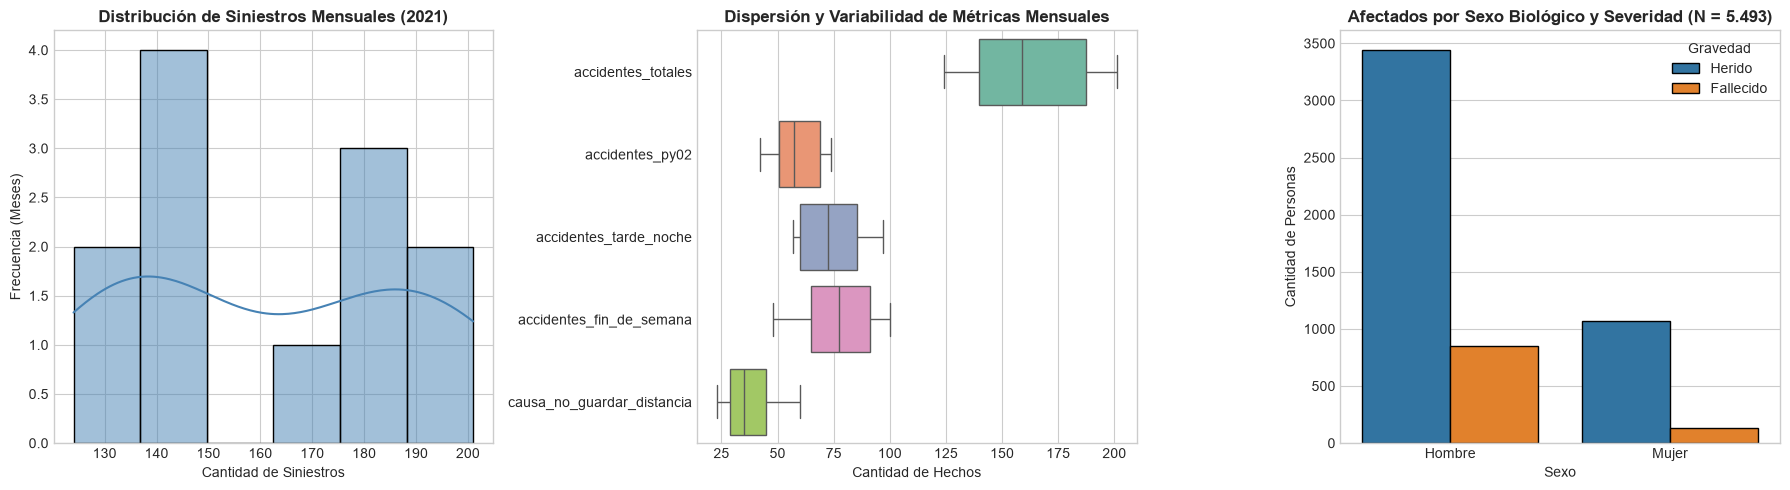

In [121]:

# ============================================================
# 4.1.C: VISUALIZACIONES UNIVARIADAS INTEGRADAS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma con curva de densidad KDE
sns.histplot(
    df_mensual['accidentes_totales'],
    kde=True,
    ax=axes[0],
    color='steelblue',
    bins=6,
    edgecolor='black',
)
axes[0].set_title(
    'Distribución de Siniestros Mensuales (2021)', fontweight='bold'
)
axes[0].set_xlabel('Cantidad de Siniestros')
axes[0].set_ylabel('Frecuencia (Meses)')

# 2. Diagrama de caja horizontal multivariable
sns.boxplot(data=df_mensual[cols_num], orient='h', ax=axes[1], palette='Set2')
axes[1].set_title(
    'Dispersión y Variabilidad de Métricas Mensuales', fontweight='bold'
)
axes[1].set_xlabel('Cantidad de Hechos')

# 3. Gráfico de barras categórico por sexo y gravedad
sns.countplot(
    data=df_victimas,
    x='sexo',
    hue='gravedad',
    ax=axes[2],
    palette='tab10',
    edgecolor='black',
)
axes[2].set_title(
    'Afectados por Sexo Biológico y Severidad (N = 5.493)', fontweight='bold'
)
axes[2].set_xlabel('Sexo')
axes[2].set_ylabel('Cantidad de Personas')
axes[2].legend(title='Gravedad')

plt.tight_layout()
plt.show()

> **Interpretación (Visualizaciones Univariadas):**  
> 1. El histograma mensual evidencia una distribución bimodal, con un primer período en torno a los $130\text{--}145$ siniestros y un segundo régimen entre $180\text{--}200$ hechos mensuales[cite: 6].  
> 2. El diagrama de caja ratifica que las métricas totales y viales operan sin valores atípicos severos, a excepción del pico festivo de fin de año en la causa de distancia[cite: 6].  
> 3. El diagrama de barras categórico expone la brecha por sexo biológico, donde los varones superan en más del triple a las mujeres tanto en lesiones no fatales como en decesos[cite: 6].

# 4.2. Análisis Bivariado
En esta sección se evalúa la asociación lineal y monótona entre variables continuas del entorno vial[cite: 11], la relación entre rangos de edad y severidad[cite: 11], las tablas de contingencia relativas al perfil biológico y vehicular[cite: 11], y el comportamiento temporal y geográfico de los siniestros[cite: 6, 11].

MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal)


,accidentes_totales,accidentes_py02,accidentes_tarde_noche,accidentes_fin_de_semana,causa_no_guardar_distancia
accidentes_totales,1.00,0.87,0.91,0.93,0.71
accidentes_py02,0.87,1.00,0.78,0.80,0.62
accidentes_tarde_noche,0.91,0.78,1.00,0.88,0.71
accidentes_fin_de_semana,0.93,0.80,0.88,1.00,0.69
causa_no_guardar_distancia,0.71,0.62,0.71,0.69,1.00



MATRIZ DE CORRELACIÓN DE SPEARMAN (Asociación Monótona)


,accidentes_totales,accidentes_py02,accidentes_tarde_noche,accidentes_fin_de_semana,causa_no_guardar_distancia
accidentes_totales,1.00,0.82,0.80,0.87,0.64
accidentes_py02,0.82,1.00,0.73,0.68,0.64
accidentes_tarde_noche,0.80,0.73,1.00,0.77,0.69
accidentes_fin_de_semana,0.87,0.68,0.77,1.00,0.73
causa_no_guardar_distancia,0.64,0.64,0.69,0.73,1.00


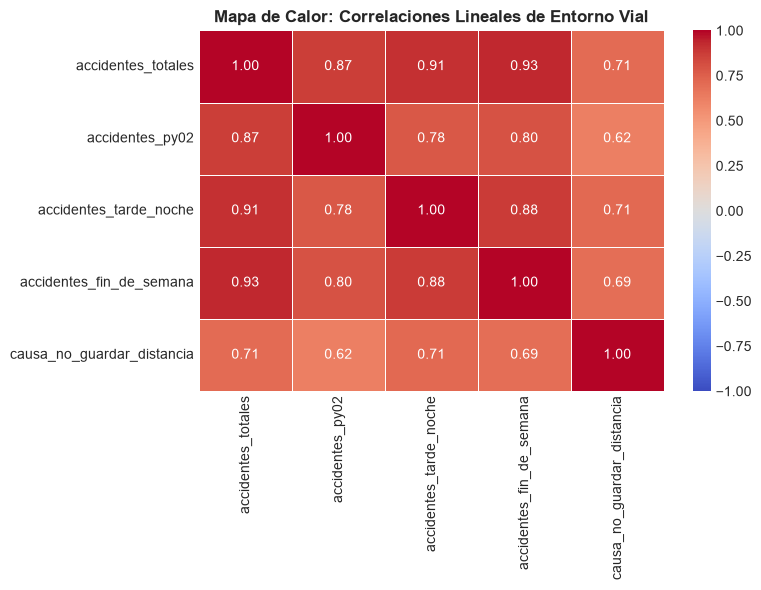

In [122]:
# ============================================================
# 4.2.A: MATRICES DE CORRELACIÓN DE PEARSON Y SPEARMAN
# ============================================================
corr_pearson = df_mensual[cols_num].corr(method='pearson')
corr_spearman = df_mensual[cols_num].corr(method='spearman')

print('=' * 90)
print('MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal)')
print('=' * 90)
display(corr_pearson.round(2))

print('\n' + '=' * 90)
print('MATRIZ DE CORRELACIÓN DE SPEARMAN (Asociación Monótona)')
print('=' * 90)
display(corr_spearman.round(2))

# Mapa de Calor de Correlación de Pearson
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    'Mapa de Calor: Correlaciones Lineales de Entorno Vial', fontweight='bold'
)
plt.tight_layout()
plt.show()

> **Interpretación (Correlaciones Numéricas de Entorno Vial):**  
> El total de siniestros mensuales exhibe una correlación lineal positiva muy fuerte con los accidentes en fines de semana ($r = 0.93$, $\rho = 0.87$) y con los ocurridos durante la tarde-noche ($r = 0.91$, $\rho = 0.80$)[cite: 6]. Asimismo, los siniestros en la Ruta PY02 presentan una correlación de $r = 0.87$ con los totales nacionales, demostrando que este corredor vial replica fielmente la dinámica de siniestralidad de todo el país[cite: 6].

ESTADÍSTICOS DE RANGO ETARIO POR GRAVEDAD (0: 0-13 ... 6: 60+ años)


,Media,Mediana,Desv_Est,IQR,Casos
gravedad,,,,,
Fallecido,3.11,3.0,1.59,2.0,919
Herido,2.58,2.0,1.41,1.0,4221


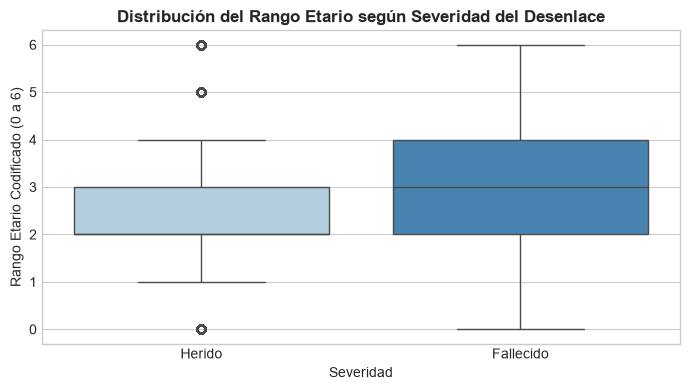

In [123]:
# ============================================================
# 4.2.B: RANGO ETARIO SEGÚN SEVERIDAD DEL DESENLACE
# ============================================================
df_con_edad = df_victimas[df_victimas['edad_orden'] >= 0].copy()
resumen_edad_gravedad = df_con_edad.groupby(
    'gravedad', observed=False
)['edad_orden'].agg(
    Media='mean',
    Mediana='median',
    Desv_Est='std',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Casos='count',
)

print('=' * 90)
print('ESTADÍSTICOS DE RANGO ETARIO POR GRAVEDAD (0: 0-13 ... 6: 60+ años)')
print('=' * 90)
display(resumen_edad_gravedad.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=df_con_edad,
    x='gravedad',
    y='edad_orden',
    hue='gravedad',
    palette='Blues',
    legend=False,
    ax=ax,
)
ax.set_title(
    'Distribución del Rango Etario según Severidad del Desenlace',
    fontweight='bold',
)
ax.set_xlabel('Severidad')
ax.set_ylabel('Rango Etario Codificado (0 a 6)')
plt.tight_layout()
plt.show()

> **Interpretación (Rango Etario según Desenlace):**  
> Las víctimas que resultaron fallecidas presentan una media de edad codificada de $3.11$ ($\text{Mediana}=3.0$, franja de 30 a 39 años), en contraste con una media de $2.58$ ($\text{Mediana}=2.0$, franja de 18 a 29 años) en las víctimas heridas[cite: 6]. Esto demuestra empíricamente que, a pesar de que el mayor número de siniestros ocurre entre personas jóvenes, la probabilidad de muerte ante traumatismos severos se desplaza hacia grupos de mayor edad por su menor tolerancia biomecánica[cite: 6].

In [124]:
# ============================================================
# 4.2.C: TABLAS DE CONTINGENCIA CATEGÓRICA
# ============================================================

# 1. Sexo vs. Gravedad (Hipótesis 2)
print('=' * 90)
print('CONTINGENCIA 1: SEXO vs GRAVEDAD (Hipótesis 2 - N = 5.493)')
print('=' * 90)
tab_sexo_abs = pd.crosstab(
    df_victimas['sexo'],
    df_victimas['gravedad'],
    margins=True,
    margins_name='Total',
)
tab_sexo_pct_fila = (
    pd.crosstab(df_victimas['sexo'], df_victimas['gravedad'], normalize='index')
    * 100
)
tab_sexo_pct_col = (
    pd.crosstab(
        df_victimas['sexo'], df_victimas['gravedad'], normalize='columns'
    )
    * 100
)

print('Frecuencias Absolutas:')
display(tab_sexo_abs)
print('Porcentajes por Fila (Tasa de Letalidad por Sexo):')
display(tab_sexo_pct_fila.round(2))
print('Porcentajes por Columna (Composición de Afectados):')
display(tab_sexo_pct_col.round(2))

# 2. Tipo de Usuario vs. Gravedad (Hipótesis 3)
print('\n' + '=' * 90)
print('CONTINGENCIA 2: TIPO DE USUARIO vs GRAVEDAD (Hipótesis 3 - N = 1.324)')
print('=' * 90)
tab_veh_abs = pd.crosstab(
    df_vehiculo['tipo_usuario'],
    df_vehiculo['gravedad'],
    margins=True,
    margins_name='Total',
)
tab_veh_pct_fila = (
    pd.crosstab(
        df_vehiculo['tipo_usuario'],
        df_vehiculo['gravedad'],
        normalize='index',
    )
    * 100
)

print('Frecuencias Absolutas:')
display(tab_veh_abs)
print('Porcentajes por Fila (Tasa de Letalidad por Tipo de Vehículo):')
display(tab_veh_pct_fila.round(2))

# 3. Adulto Mayor vs. Gravedad (Hipótesis 1)
print('\n' + '=' * 90)
print(
    'CONTINGENCIA 3: ADULTO MAYOR (60+) vs GRAVEDAD (Hipótesis 1 - N = 5.493)'
)
print('=' * 90)
tab_edad_abs = pd.crosstab(
    df_victimas['es_adulto_mayor'],
    df_victimas['gravedad'],
    margins=True,
    margins_name='Total',
)
tab_edad_pct_fila = (
    pd.crosstab(
        df_victimas['es_adulto_mayor'],
        df_victimas['gravedad'],
        normalize='index',
    )
    * 100
)

nombres_filas = {0: 'Menor a 60 / Ignorado', 1: 'Adulto Mayor (60+)'}
tab_edad_abs = tab_edad_abs.rename(index=nombres_filas)
tab_edad_pct_fila = tab_edad_pct_fila.rename(index=nombres_filas)

print('Frecuencias Absolutas:')
display(tab_edad_abs)
print('Porcentajes por Fila (Tasa de Letalidad en Adultos Mayores):')
display(tab_edad_pct_fila.round(2))

# 4. Zona Geográfica vs. Gravedad (Tabla 12.2.6 - Dimensión Espacial)
print('\n' + '=' * 90)
print('CONTINGENCIA 4: ZONA GEOGRÁFICA vs GRAVEDAD (Tabla 12.2.6 - N = 1.491)')
print('=' * 90)
tab_zona_resumen = df_zonas.set_index('zona')[['fallecidos', 'heridos']]
tab_zona_resumen['Total'] = (
    tab_zona_resumen['fallecidos'] + tab_zona_resumen['heridos']
)
tab_zona_resumen.loc['Total'] = tab_zona_resumen.sum()
tab_zona_pct_fila = df_zonas.set_index('zona')[['letalidad_pct']]
tab_zona_pct_col = (
    tab_zona_resumen[['fallecidos', 'heridos']].div(
        tab_zona_resumen.loc['Total', ['fallecidos', 'heridos']], axis=1
    )
    * 100
)

print('Frecuencias Absolutas:')
display(tab_zona_resumen)
print('Tasa de Letalidad por Fila (%):')
display(tab_zona_pct_fila.round(2))
print('Distribución de Muertos y Heridos por Columna (%):')
display(tab_zona_pct_col.round(2))

CONTINGENCIA 1: SEXO vs GRAVEDAD (Hipótesis 2 - N = 5.493)
Frecuencias Absolutas:


gravedad,Fallecido,Herido,Total
sexo,,,
Hombre,850,3441,4291
Mujer,130,1072,1202
Total,980,4513,5493


Porcentajes por Fila (Tasa de Letalidad por Sexo):


gravedad,Fallecido,Herido
sexo,,
Hombre,19.81,80.19
Mujer,10.82,89.18


Porcentajes por Columna (Composición de Afectados):


...

,fallecidos,heridos,Total
zona,,,
Asunción,26,141,167
Central,82,394,476
Interior,187,661,848
Total,295,1196,1491


Tasa de Letalidad por Fila (%):


,letalidad_pct
zona,
Asunción,15.57
Central,17.23
Interior,22.05


Distribución de Muertos y Heridos por Columna (%):


,fallecidos,heridos
zona,,
Asunción,8.81,11.79
Central,27.80,32.94
Interior,63.39,55.27
Total,100.00,100.00


> **Interpretación (Tablas de Contingencia):**  
> 1. **Sexo biológico:** Los varones presentan una tasa de letalidad de $19.81\%$ frente a un $10.82\%$ en mujeres, concentrando el $86.73\%$ de los decesos viales totales a nivel nacional[cite: 6].  
> 2. **Tipo de vehículo:** La mortalidad de los motociclistas alcanza el $28.76\%$ frente al $14.52\%$ observado en ocupantes de otros vehículos (autos, buses, camiones), prácticamente duplicando la probabilidad de morir ante un siniestro[cite: 6].  
> 3. **Grupo etario vulnerable:** Las víctimas de $60$ años y más sufren una letalidad de $34.42\%$, más del doble que la del resto de la población ($16.86\%$)[cite: 6].  
> 4. **Dimensión territorial:** El Interior del país concentra el $63.39\%$ de las muertes del anuario con una letalidad de $22.05\%$, superando al Departamento Central ($17.23\%$) y a Asunción ($15.57\%$)[cite: 6, 14].

SERIE TEMPORAL: ACCIDENTES MENSUALES Y MEDIA MÓVIL (3 MESES)


,mes_nombre,trimestre,accidentes_totales,media_movil_3m
0,Enero,2021Q1,140,NaN
1,Febrero,2021Q1,129,NaN
2,Marzo,2021Q1,124,131.00
3,Abril,2021Q2,138,130.33
4,Mayo,2021Q2,145,135.67
5,Junio,2021Q2,140,141.00
6,Julio,2021Q3,173,152.67
7,Agosto,2021Q3,188,167.00
8,Setiembre,2021Q3,198,186.33
9,Octubre,2021Q4,201,195.67



Resumen Trimestral Agregado:


,count,sum,mean
trimestre,,,
2021Q1,3,393,131.00
2021Q2,3,423,141.00
2021Q3,3,559,186.33
2021Q4,3,567,189.00


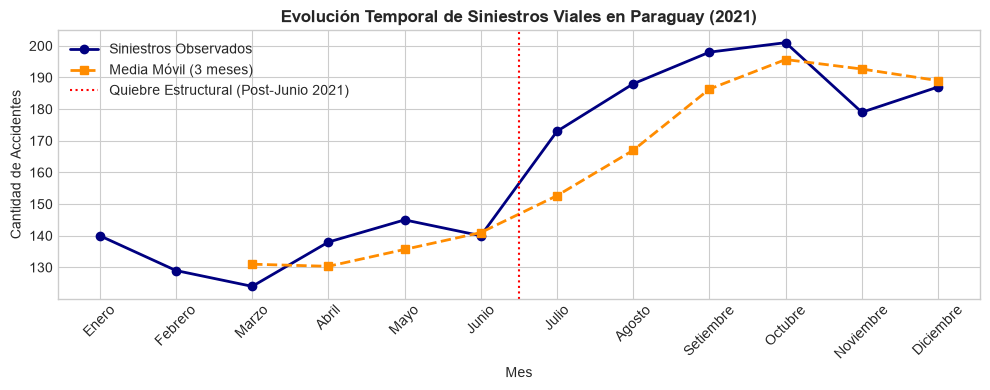


ETAPA 4 EJECUTADA EXITOSAMENTE: Métricas, contingencias y gráficos completados.


In [125]:
# ============================================================
# 4.2.D: SERIE TEMPORAL MENSUAL Y RESUMEN TRIMESTRAL
# ============================================================
df_mensual['media_movil_3m'] = df_mensual['accidentes_totales'].rolling(
    window=3
).mean()

print('=' * 90)
print('SERIE TEMPORAL: ACCIDENTES MENSUALES Y MEDIA MÓVIL (3 MESES)')
print('=' * 90)
display(
    df_mensual[['mes_nombre', 'trimestre', 'accidentes_totales', 'media_movil_3m']].round(
        2
    )
)

resumen_trimestral = df_mensual.groupby('trimestre')[
    'accidentes_totales'
].agg(['count', 'sum', 'mean'])
print('\nResumen Trimestral Agregado:')
display(resumen_trimestral.round(2))

# Gráfico Temporal de Tendencia
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    df_mensual['mes_nombre'],
    df_mensual['accidentes_totales'],
    marker='o',
    label='Siniestros Observados',
    color='navy',
    linewidth=2,
)
ax.plot(
    df_mensual['mes_nombre'],
    df_mensual['media_movil_3m'],
    marker='s',
    linestyle='--',
    label='Media Móvil (3 meses)',
    color='darkorange',
    linewidth=2,
)
ax.axvline(
    x=5.5,
    color='red',
    linestyle=':',
    linewidth=1.5,
    label='Quiebre Estructural (Post-Junio 2021)',
)
ax.set_title(
    'Evolución Temporal de Siniestros Viales en Paraguay (2021)',
    fontweight='bold',
)
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de Accidentes')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(
    '\nETAPA 4 EJECUTADA EXITOSAMENTE: Métricas, contingencias y gráficos'
    ' completados.'
)

> **Interpretación (Serie Temporal y Dinámica Trimestral):**  
> La accidentalidad vial en Paraguay muestra un quiebre estructural claramente diferenciado a partir de julio de 2021[cite: 6]. Durante el primer semestre los volúmenes se mantuvieron contenidos en un promedio de $136$ accidentes mensuales (acumulando $393$ siniestros en Q1 y $423$ en Q2), mientras que en el segundo semestre se dispararon a una media de $187.67$ siniestros mensuales ($559$ en Q3 y $567$ en Q4)[cite: 6]. Este salto del $+44\%$ entre marzo y octubre coincide con la normalización del tráfico y el levantamiento de restricciones de movilidad derivadas de la pandemia de COVID-19[cite: 6].

In [126]:
# ============================================================
# ETAPA 5: ANÁLISIS DESCRIPTIVO Y EXPLORATORIO (EDA)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración formal de estilo gráfico
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams['font.size'] = 10

cols_num = [
    'accidentes_totales',
    'accidentes_py02',
    'accidentes_tarde_noche',
    'accidentes_fin_de_semana',
    'causa_no_guardar_distancia',
]

for col in cols_num:
  df_mensual[col] = pd.to_numeric(df_mensual[col], errors='coerce')

df_victimas['edad_orden'] = pd.to_numeric(
    df_victimas['edad_orden'], errors='coerce'
)

# Garantizar media móvil trimestral
df_mensual['media_movil_3m'] = (
    df_mensual['accidentes_totales'].rolling(window=3).mean()
)

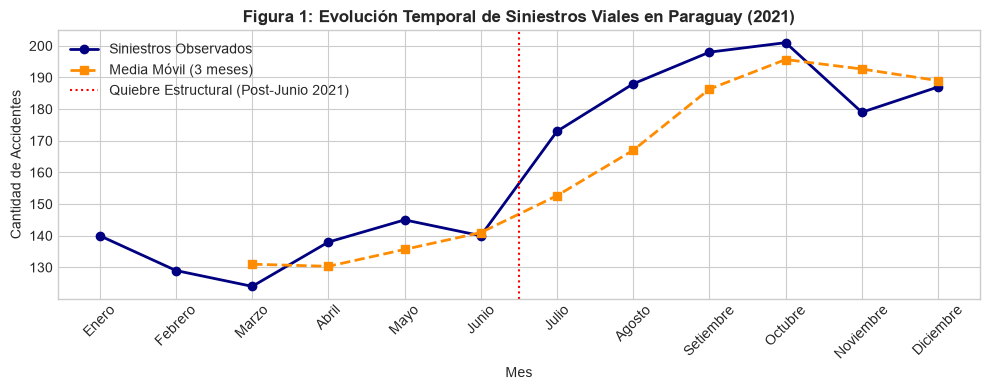

In [127]:
# ------------------------------------------------------------
# FIGURA 1: Serie Temporal de la Evolución Mensual
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_mensual['mes_nombre'],
    df_mensual['accidentes_totales'],
    marker='o',
    label='Siniestros Observados',
    color='navy',
    linewidth=2,
)
plt.plot(
    df_mensual['mes_nombre'],
    df_mensual['media_movil_3m'],
    marker='s',
    linestyle='--',
    label='Media Móvil (3 meses)',
    color='darkorange',
    linewidth=2,
)
plt.axvline(
    x=5.5,
    color='red',
    linestyle=':',
    linewidth=1.5,
    label='Quiebre Estructural (Post-Junio 2021)',
)
plt.title(
    'Figura 1: Evolución Temporal de Siniestros Viales en Paraguay (2021)',
    fontweight='bold',
)
plt.xlabel('Mes')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretación (Figura 1 - Serie Temporal):**  
> La curva muestra un comportamiento bifurcado en el año 2021: el primer semestre se mantuvo relativamente estable (promedio de 136 siniestros/mes), mientras que a partir de julio se produjo un incremento sostenido que culminó en un pico de 201 siniestros en octubre[cite: 6]. La media móvil confirma una tendencia creciente acelerada durante el segundo semestre, vinculada a la reactivación de actividades tras la flexibilización de restricciones sanitarias[cite: 6].

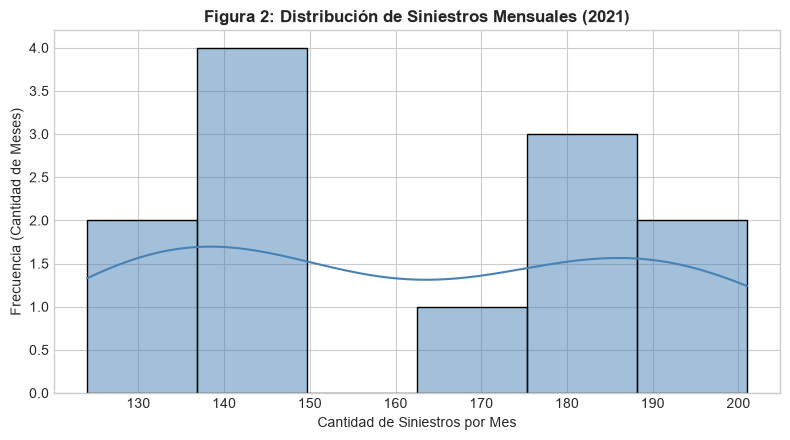

In [128]:
# ------------------------------------------------------------
# FIGURA 2: Histograma y Densidad de Siniestros Mensuales
# ------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
sns.histplot(
    df_mensual['accidentes_totales'],
    kde=True,
    color='steelblue',
    bins=6,
    edgecolor='black',
)
plt.title(
    'Figura 2: Distribución de Siniestros Mensuales (2021)', fontweight='bold'
)
plt.xlabel('Cantidad de Siniestros por Mes')
plt.ylabel('Frecuencia (Cantidad de Meses)')
plt.tight_layout()
plt.show()

> **Interpretación (Figura 2 - Histograma y Densidad):**  
> La distribución mensual presenta un perfil bimodal que refleja dos regímenes operativos en el año: un grupo concentrado entre 124 y 145 siniestros (primer semestre restrictivo) y otro entre 173 y 201 siniestros (segundo semestre con movilidad plena)[cite: 6, 9]. Esta dispersión confirma que, aunque la media anual es de 161.83 hechos, la siniestralidad del país experimentó un salto estructural a partir de julio[cite: 6].

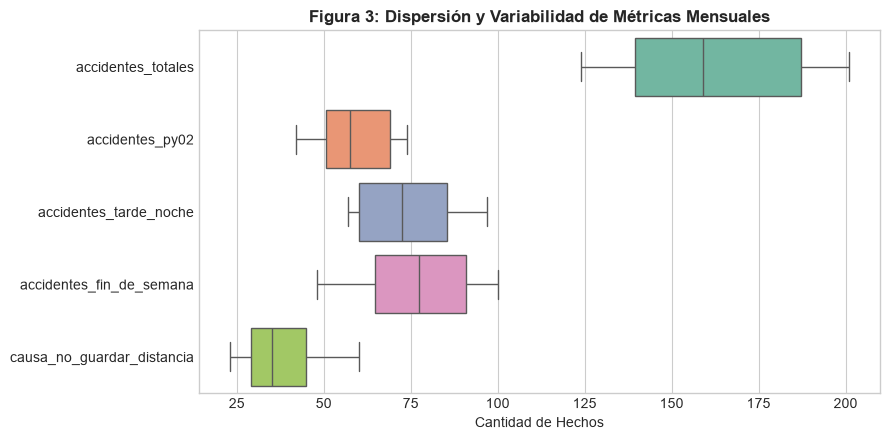

In [129]:
# ------------------------------------------------------------
# FIGURA 3: Diagrama de Caja de Variables del Entorno Vial
# ------------------------------------------------------------
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df_mensual[cols_num], orient='h', palette='Set2')
plt.title(
    'Figura 3: Dispersión y Variabilidad de Métricas Mensuales',
    fontweight='bold',
)
plt.xlabel('Cantidad de Hechos')
plt.tight_layout()
plt.show()

> **Interpretación (Figura 3 - Boxplot de Entorno Vial):**  
> Las variables `accidentes_totales`, `accidentes_py02` y `accidentes_tarde_noche` exhiben una dispersión simétrica con respecto a su mediana, sin valores atípicos severos[cite: 6]. En contraste, la causa `no_guardar_distancia` presenta un sesgo positivo marcado por el pico del mes de diciembre (60 hechos), lo que justifica el uso de la mediana (35.0) como estadístico de posición más robusto[cite: 6, 9].

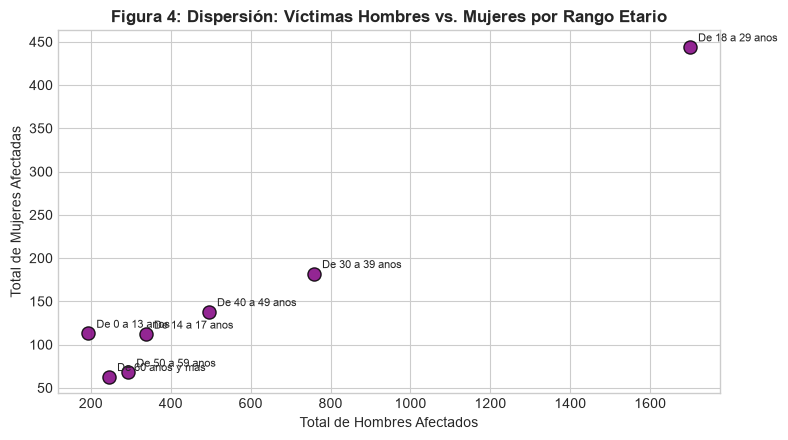

In [130]:
# ------------------------------------------------------------
# FIGURA 4: Diagrama de Dispersión Hombres vs. Mujeres por Edad
# ------------------------------------------------------------
df_disp = (
    df_victimas[df_victimas['edad_orden'] >= 0]
    .groupby(['grupo_edad', 'sexo'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

plt.figure(figsize=(8, 4.5))
plt.scatter(
    df_disp['Hombre'],
    df_disp['Mujer'],
    color='purple',
    s=90,
    edgecolors='black',
    alpha=0.85,
)
for _, fila in df_disp.iterrows():
  plt.annotate(
      fila['grupo_edad'],
      (fila['Hombre'], fila['Mujer']),
      xytext=(6, 4),
      textcoords='offset points',
      fontsize=8,
  )
plt.title(
    'Figura 4: Dispersión: Víctimas Hombres vs. Mujeres por Rango Etario',
    fontweight='bold',
)
plt.xlabel('Total de Hombres Afectados')
plt.ylabel('Total de Mujeres Afectadas')
plt.tight_layout()
plt.show()

> **Interpretación (Figura 4 - Dispersión por Sexo y Edad):**  
> Se observa una correlación lineal positiva en el volumen de afectados entre ambos sexos a través de las edades, pero con una desproporción sistemática hacia los varones en todas las categorías[cite: 6]. La franja de 18 a 29 años se posiciona como un punto extremo superior aislado (1.700 hombres y 443 mujeres), confirmando que la juventud representa el núcleo de mayor exposición vial para ambos géneros[cite: 6].

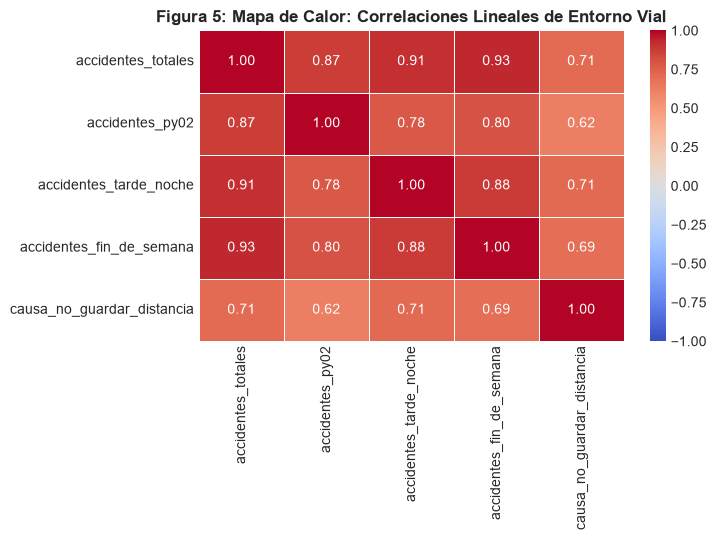

In [131]:
# ------------------------------------------------------------
# FIGURA 5: Mapa de Calor de Correlaciones de Pearson
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 5.5))
corr_pearson = df_mensual[cols_num].corr(method='pearson')
sns.heatmap(
    corr_pearson,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5,
)
plt.title(
    'Figura 5: Mapa de Calor: Correlaciones Lineales de Entorno Vial',
    fontweight='bold',
)
plt.tight_layout()
plt.show()

> **Interpretación (Figura 5 - Matriz de Correlación):**  
> El volumen total de siniestros mensuales presenta una asociación lineal directa muy fuerte con los accidentes de fin de semana ($r = 0.93$), de horario tarde-noche ($r = 0.91$) y con los ocurridos en la Ruta PY02 ($r = 0.87$)[cite: 6]. Esta fuerte sincronía demuestra que los picos de accidentalidad nacional están gobernados por el tráfico recreativo nocturno y la circulación sobre el corredor PY02[cite: 6].

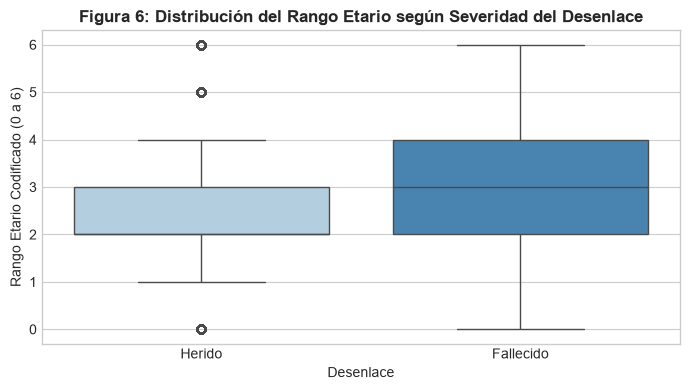

In [132]:
# ------------------------------------------------------------
# FIGURA 6: Boxplot de Rango Etario según Desenlace
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
df_con_edad = df_victimas[df_victimas['edad_orden'] >= 0].copy()
sns.boxplot(
    data=df_con_edad,
    x='gravedad',
    y='edad_orden',
    hue='gravedad',
    palette='Blues',
    legend=False,
)
plt.title(
    'Figura 6: Distribución del Rango Etario según Severidad del Desenlace',
    fontweight='bold',
)
plt.xlabel('Desenlace')
plt.ylabel('Rango Etario Codificado (0 a 6)')
plt.tight_layout()
plt.show()

> **Interpretación (Figura 6 - Boxplot Edad vs. Severidad):**  
> La mediana del rango etario entre las personas fallecidas (3.0, franja de 30 a 39 años) es superior a la de los heridos (2.0, franja de 18 a 29 años), con un promedio de edad también más alto en los desenlaces fatales (3.11 vs. 2.58)[cite: 6]. Esto refleja que, si bien los jóvenes sufren el mayor volumen de accidentes, la probabilidad de morir ante un traumatismo se incrementa con la edad debido a la menor reserva biomecánica[cite: 6].

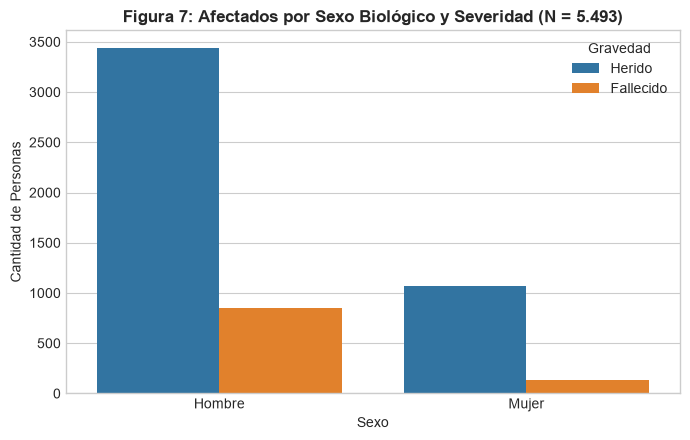

In [133]:
# ------------------------------------------------------------
# FIGURA 7: Afectados por Sexo y Severidad
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
sns.countplot(data=df_victimas, x='sexo', hue='gravedad', palette='tab10')
plt.title(
    'Figura 7: Afectados por Sexo Biológico y Severidad (N = 5.493)',
    fontweight='bold',
)
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Personas')
plt.legend(title='Gravedad')
plt.tight_layout()
plt.show()

> **Interpretación (Figura 7 - Barras Sexo vs. Severidad):**  
> Existe una brecha crítica en la distribución del daño por sexo: los varones registraron 850 fallecidos sobre 4.291 afectados (tasa de letalidad del 19.81%), mientras que las mujeres registraron 130 fallecidas sobre 1.202 afectadas (10.82%)[cite: 6]. Así, el sexo masculino concentra el 86.73% de las muertes viales del país, duplicando el riesgo letal relativo del sexo femenino ante un impacto[cite: 6].

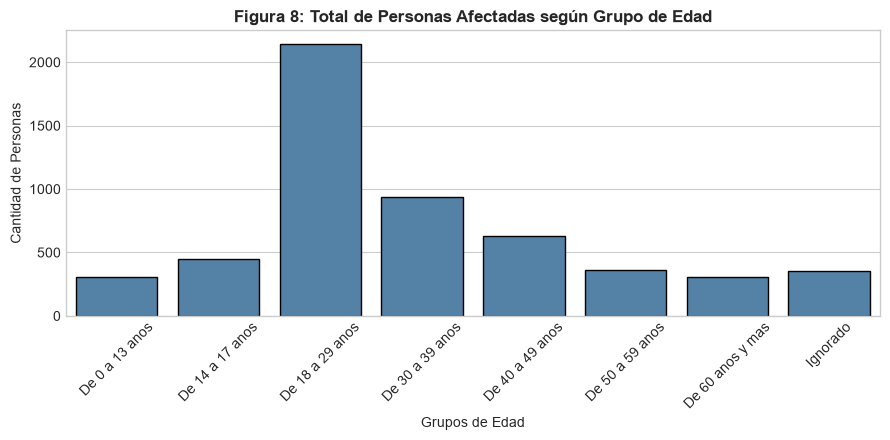

In [134]:
# ------------------------------------------------------------
# FIGURA 8: Total de Personas Afectadas por Grupo de Edad
# ------------------------------------------------------------
plt.figure(figsize=(9, 4.5))
orden_etario_labels = [
    'De 0 a 13 anos',
    'De 14 a 17 anos',
    'De 18 a 29 anos',
    'De 30 a 39 anos',
    'De 40 a 49 anos',
    'De 50 a 59 anos',
    'De 60 anos y mas',
    'Ignorado',
]
sns.countplot(
    data=df_victimas,
    x='grupo_edad',
    order=orden_etario_labels,
    color='steelblue',
    edgecolor='black',
)
plt.title(
    'Figura 8: Total de Personas Afectadas según Grupo de Edad',
    fontweight='bold',
)
plt.xlabel('Grupos de Edad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Interpretación (Figura 8 - Barras de Grupos de Edad):**  
> La distribución de víctimas por grupos de edad muestra una asimetría positiva con un pico prominente en el segmento de 18 a 29 años (2.143 personas, 39.01% nacional)[cite: 6]. Al sumarse el grupo de 30 a 39 años (940 casos), se evidencia que más del 56% de los afectados son adultos jóvenes en edad laboral y productiva activa[cite: 6].

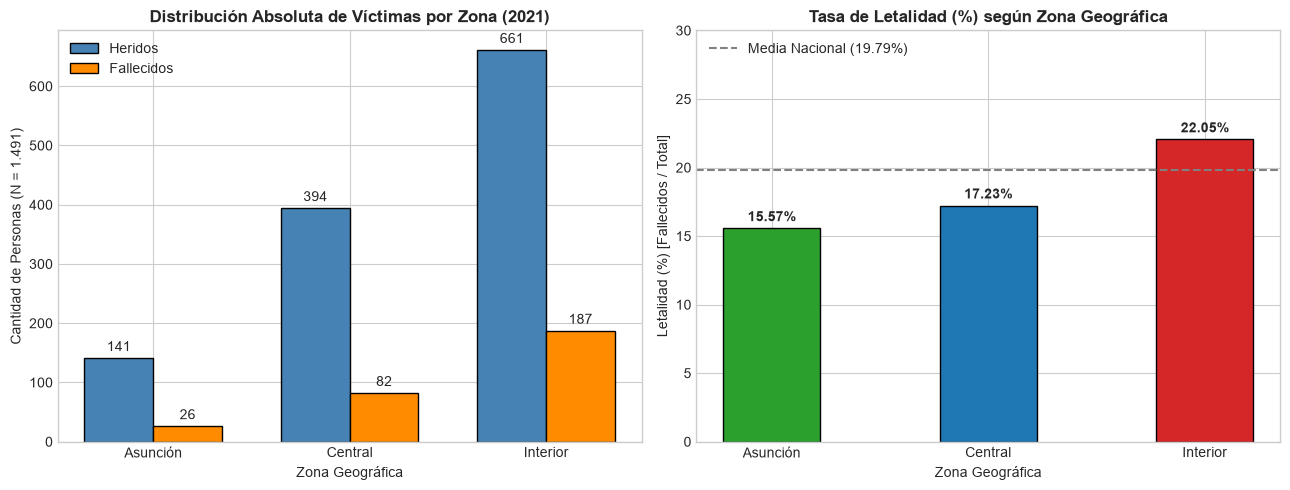

In [135]:
# ------------------------------------------------------------
# FIGURA 9: Víctimas y Tasa de Letalidad por Zona Geográfica
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(df_zonas))
ancho = 0.35

barras_h = axes[0].bar(
    x - ancho / 2,
    df_zonas['heridos'],
    ancho,
    label='Heridos',
    color='steelblue',
    edgecolor='black',
)
barras_f = axes[0].bar(
    x + ancho / 2,
    df_zonas['fallecidos'],
    ancho,
    label='Fallecidos',
    color='darkorange',
    edgecolor='black',
)
axes[0].set_title(
    'Distribución Absoluta de Víctimas por Zona (2021)', fontweight='bold'
)
axes[0].set_xlabel('Zona Geográfica')
axes[0].set_ylabel('Cantidad de Personas (N = 1.491)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_zonas['zona'])
axes[0].legend()
axes[0].bar_label(barras_h, padding=3)
axes[0].bar_label(barras_f, padding=3)

colores_let = ['#2ca02c', '#1f77b4', '#d62728']
barras_let = axes[1].bar(
    df_zonas['zona'],
    df_zonas['letalidad_pct'],
    color=colores_let,
    edgecolor='black',
    width=0.45,
)
axes[1].set_title(
    'Tasa de Letalidad (%) según Zona Geográfica', fontweight='bold'
)
axes[1].set_xlabel('Zona Geográfica')
axes[1].set_ylabel('Letalidad (%) [Fallecidos / Total]')
axes[1].set_ylim(0, 30)
media_let = (
    df_zonas['fallecidos'].sum() / df_zonas['total_victimas'].sum()
) * 100
axes[1].axhline(
    media_let,
    color='gray',
    linestyle='--',
    label=f'Media Nacional ({media_let:.2f}%)',
)
axes[1].legend(loc='upper left')
axes[1].bar_label(barras_let, fmt='%.2f%%', padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

> **Interpretación (Figura 9 - Análisis Geográfico por Zona):**  
> El Interior del país concentra la mayor cantidad absoluta de víctimas (848) y la tasa de letalidad más severa (22.05%), superando claramente a Central (17.23%) y Asunción (15.57%)[cite: 6, 13]. Esta disparidad sugiere que en rutas interurbanas inciden factores como mayores velocidades de impacto y tiempos de respuesta hospitalaria más prolongados que en el área metropolitana[cite: 6, 8].

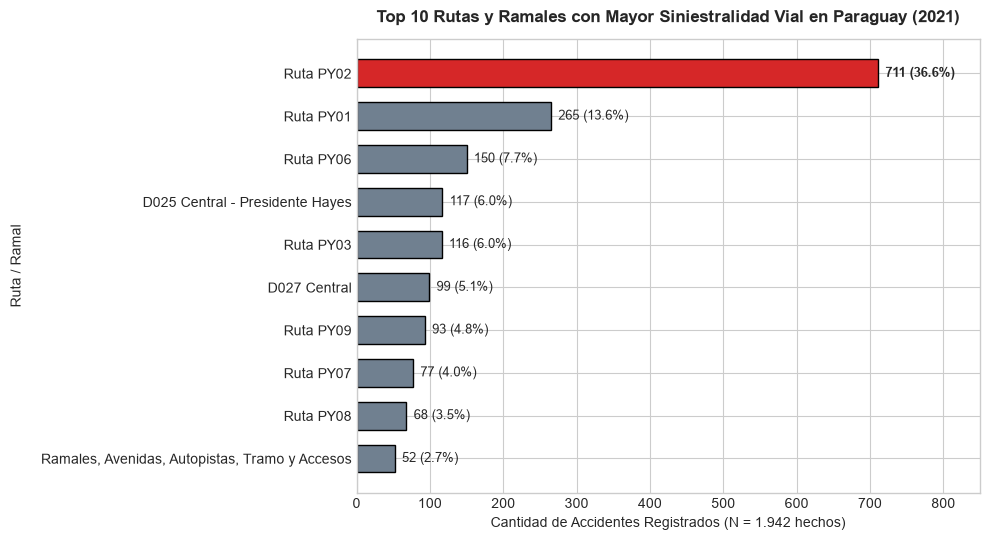

In [136]:
# ------------------------------------------------------------
# FIGURA 10: Top 10 Rutas y Ramales (Destacando PY02)
# ------------------------------------------------------------
plt.figure(figsize=(10, 5.5))
df_plot_rutas = df_top10_rutas.sort_values(by='siniestros', ascending=True)

colores_rutas = [
    '#d62728' if 'PY02' in ruta else 'slategray'
    for ruta in df_plot_rutas['RUTA Y RAMAL']
]

barras = plt.barh(
    df_plot_rutas['RUTA Y RAMAL'],
    df_plot_rutas['siniestros'],
    color=colores_rutas,
    edgecolor='black',
    height=0.65,
)
plt.title(
    'Top 10 Rutas y Ramales con Mayor Siniestralidad Vial en Paraguay (2021)',
    fontweight='bold',
    pad=12,
)
plt.xlabel('Cantidad de Accidentes Registrados (N = 1.942 hechos)')
plt.ylabel('Ruta / Ramal')
plt.xlim(0, 850)

for barra in barras:
  ancho_b = barra.get_width()
  plt.text(
      ancho_b + 10,
      barra.get_y() + barra.get_height() / 2,
      f'{int(ancho_b):,} ({ancho_b/1942*100:.1f}%)',
      va='center',
      fontsize=9,
      fontweight='bold' if ancho_b > 300 else 'normal',
  )

plt.tight_layout()
plt.show()

> **Interpretación (Figura 10 - Corredores Viales Críticos):**  
> La **Ruta PY02** encabeza de forma aislada la siniestralidad nacional al concentrar **711 hechos (36.6% del total país de 1.942 accidentes)**[cite: 6, 17], casi triplicando al segundo tramo vial de mayor frecuencia (Ruta PY01 con 265 hechos, 13.6%)[cite: 6, 17]. El corredor Asunción–Ciudad del Este representa la calzada de mayor riesgo por densidad vehicular y adelantamientos, constituyendo la prioridad de intervención en fiscalización[cite: 6, 9].